# Tinder for RL 
## RLI 22.00 · Group Assignment · IE University BCSAI · 2026

### Part 01

---

## Introduction

The MountainCar problem presented in this RL assignment is interesting because:
It's simple enough to be solved, yet it's difficult enough to show the fundamental differences between learning algorithms. MountainCar involves an under-powered car in a valley attempting to reach a flag on the top of the right hand hill. The car is too weak to drive directly up, gravity pulls it down to the valley. 

The only possible way is to learn how to build up momentum through trial and error by oscillating to the left and right until there's enough potential energy to reach the goal, an unexpected solution.


Our study is organized around four scenarios that cross two axes: **action space type** (discrete vs. continuous) and **reward/cost formulation** (minimize steps vs. minimize fuel). Within each scenario we compare two algorithms suited to that action space. Across scenarios with the same action space, we hold the algorithms fixed and vary only the reward, isolating the effect of reward engineering on the learned policy.

For the **discrete scenarios**, we compare **Q-Learning** against **DQN**. Q-Learning discretizes the state space into bins and builds an explicit lookup table, giving us a fully interpretable policy, every state's preferred action can be read directly from the table and visualized as a phase portrait. DQN replaces that table with a neural network, operating on the raw continuous state without discretization loss. The comparison directly answers whether function approximation adds value on a problem this small, or whether the tabular method is already sufficient.

For the **continuous scenarios**, tabular methods are infeasible. We compare **TD3** and **SAC**, both actor-critic algorithms that learn a policy network alongside a value estimator. TD3 is deterministic: it outputs a single action per state and stabilizes training through twin critics and delayed updates. SAC is stochastic: it maximizes a entropy-augmented objective, explicitly rewarding the agent for maintaining an exploratory, spread-out policy. This entropy regularization is particularly relevant here: in scenarios where large actions are penalized, SAC's natural tendency toward low-magnitude, high-entropy behavior aligns directly with the cost structure of the problem.

The four scenarios together enable both algorithm benchmarking and a principled analysis of how reward shaping alters policy structure (which is, ultimately, what this assignment is about).






---



## Scenario 1 — Discrete MountainCar: Minimum Steps

**Environment**: `MountainCar-v0` · **Objective**: Reach the goal in as few timesteps as possible

---

The first scenario uses the discrete version of MountainCar with its default reward structure: the agent receives **−1 for every timestep** until it reaches the flag. The default environment provides no partial credit or progress signal (just a constant −1 penalty per timestep), so both algorithms add a +100 goal bonus during training to enable discovery, while evaluation uses the unmodified reward to measure true performance.

This makes the problem deceptively hard: 

the agent must stumble upon the goal through exploration before it can learn anything meaningful, and early in training almost every episode simply truncates at 200 steps.

The action space has three choices at each step: push left (0), do nothing (1), or push right (2). The optimal policy is not "always push right", the car would lack the torque to climb directly. It must learn to rock back and forth, building kinetic energy through momentum before committing to the final climb. This emergent behavior is what makes Scenario 1 a clean test of whether an algorithm can discover a multi-step, physically-grounded strategy from a sparse, undifferentiated reward signal.


### Algorithms

**Q-Learning** discretizes the continuous state space into a **40×40 grid** (position × velocity), yielding 1,600 discrete states. Each cell maps to a Q-value for each of the 3 actions, updated via the Bellman equation with a learning rate of **α = 0.1**, small enough for stable updates, large enough to learn within 25,000 episodes. The discount factor **γ = 0.99** keeps future rewards nearly as valuable as immediate ones, which matters here because the goal can only be reached many steps into the future. Exploration follows ε-greedy decay from **1.0 → 0.02** at a rate of **0.9997 per episode**, giving the agent a long exploratory phase before committing to a policy. Because the default −1/step signal is too sparse for tabular bootstrapping to work reliably, we add a **+100 goal bonus** on termination, this preserves the optimal policy ordering while giving the Q-table a concrete value to propagate backwards from. All randomness is seeded at **seed = 42**, applied to both `np.random` and the environment reset.

**DQN** uses the **same +100 goal bonus**, applied via a `ShapedMountainCar` gym wrapper that intercepts the reward on termination before it reaches the replay buffer. This is a deliberate design choice: by keeping the reward structure identical across both algorithms, any performance difference in Scenario 1 is attributable to the algorithm itself (tabular vs. function approximation)  rather than to asymmetric learning signals. The network is a **two-layer MLP [128, 128]** mapping the raw continuous state directly to Q-values. Learning rate is **5e-4**, with a **replay buffer of 50,000 transitions** and a **1,000-step warmup** before any gradient updates. Batches of **64 transitions** are sampled every **4 environment steps**, and the target network hard-updates every **1,000 steps**. Exploration decays from **1.0 → 0.02** over **35% of total timesteps**. Trained for **200,000 environment steps** at **seed = 42**.

Both algorithms are evaluated on the **unmodified −1/step reward**, the shaping is training-only. This separates the engineered learning signal from the true objective performance, making the evaluation metrics directly comparable across scenarios.

In [17]:
import json
import pickle
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stable_baselines3 import DQN, SAC, TD3

## Step 1: Load and Compare Scenario 1 Results

In this first step, we load the saved evaluation metrics for **Scenario 1: Discrete MountainCar - Minimum Steps**.

The goal of this scenario is to compare two algorithms:

- **Q-learning with a Q-table**
- **Deep Q-Network (DQN)**

Both algorithms were trained on the same environment, `MountainCar-v0`, with the objective of reaching the goal in the fewest possible steps.


The evaluation results show that **Q-Learning performed better than DQN in Scenario 1**. Q-Learning reached a **100% success rate**, while DQN reached **81%**. Q-Learning also required fewer steps on average, with about **125 steps** compared to DQN’s **160 steps**.

The reward values follow the same pattern. Since MountainCar gives a negative reward for each step, a less negative reward is better. Therefore, Q-Learning’s average reward of **-125.31** is better than DQN’s **-160.05**.

Q-Learning also used less fuel on average, meaning it reached the goal with fewer non-neutral actions. However, DQN trained faster, taking about **33.63 seconds**, while Q-Learning took about **72.85 seconds**.

The steps comparison shows that **Q-Learning reached the goal more efficiently**, needing only **125.31 steps on average**, while **DQN required 160.05 steps on average**, meaning DQN took longer paths or failed to reach the goal more often.


Overall, these results suggest that for this simple discrete environment, **Q-Learning was more reliable and efficient**, while **DQN was faster to train but less consistent**.


**Finding**: Tabular methods remain superior for **small discrete** state spaces. The exact value storage and complete state exploration of **Q-learning outweighed DQN**'s generalization capabilities in this low-dimensional problem.


In [18]:
# Notebook is in root, results are in training/results/
METRICS_DIR = Path("training/results/scenario1/metrics")

# Check if path exists, if not try alternate location
if not METRICS_DIR.exists():
    METRICS_DIR = Path("results/scenario1/metrics")
    if not METRICS_DIR.exists():
        print("❌ Error: Results not found!")
        print("Make sure you've run the training scripts first:")
        print("  python training/scenario1_qlearning.py")
        print("  python training/scenario1_dqn.py")
        raise FileNotFoundError(f"No results found at {METRICS_DIR}")

with open(METRICS_DIR / "scenario1_qtable.json") as f:
    qtable_metrics = json.load(f)

with open(METRICS_DIR / "scenario1_dqn.json") as f:
    dqn_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)",     "success_rate_percent"),
    ("Avg Reward",           "average_reward"),
    ("Avg Steps",            "average_steps"),
    ("Avg Fuel",             "average_fuel"),
    ("Min Steps",            "min_steps"),
    ("Max Steps",            "max_steps"),
    ("Training Time (s)",    "training_time_seconds"),
]

print("=" * 57)
print("SCENARIO 1: Discrete MountainCar - Minimum Steps")
print("=" * 57)
print(f"{'Metric':<25} {'Q-Learning':>15} {'DQN':>15}")
print("-" * 57)
for label, key in metrics_to_show:
    q_val = qtable_metrics.get(key, "N/A")
    d_val = dqn_metrics.get(key, "N/A")
    if isinstance(q_val, float):
        print(f"{label:<25} {q_val:>15.2f} {d_val:>15.2f}")
    else:
        print(f"{label:<25} {str(q_val):>15} {str(d_val):>15}")
print("=" * 57)

SCENARIO 1: Discrete MountainCar - Minimum Steps
Metric                         Q-Learning             DQN
---------------------------------------------------------
Success Rate (%)                   100.00           81.00
Avg Reward                        -125.31         -160.05
Avg Steps                          125.31          160.05
Avg Fuel                           107.71          156.42
Min Steps                              95              97
Max Steps                             158             200
Training Time (s)                   72.85           33.63


## Step 2: Visualize Scenario 1 Training Curves

In this step, we load and display the saved training plots for **Scenario 1: Discrete MountainCar - Minimum Steps**.

The figure compares the learning behavior of:

- **Q-Learning**, shown on the left
- **DQN**, shown on the right

Each plot contains three training curves:

- **Reward**: shows how the agent’s performance improves during training
- **Steps**: shows whether the agent reaches the goal faster over time
- **Success Rate (%)**: shows how often the agent successfully reaches the goal

From the results, **Q-Learning shows a more stable learning pattern**. After around 7,000–8,000 episodes, its success rate becomes very high and stays close to 100% for most of the remaining training. The average number of steps also decreases, meaning the agent learns to reach the goal more efficiently.

The **DQN model also improves**, but its training is much noisier. Its reward increases and the number of steps decreases over time, but the success rate fluctuates more strongly. This suggests that DQN is learning the task, but its training is less stable than the Q-table approach in this simple discrete environment.

Overall, for Scenario 1, the training curves suggest that **Q-Learning performs more reliably**, while **DQN learns more gradually and with higher variance**.

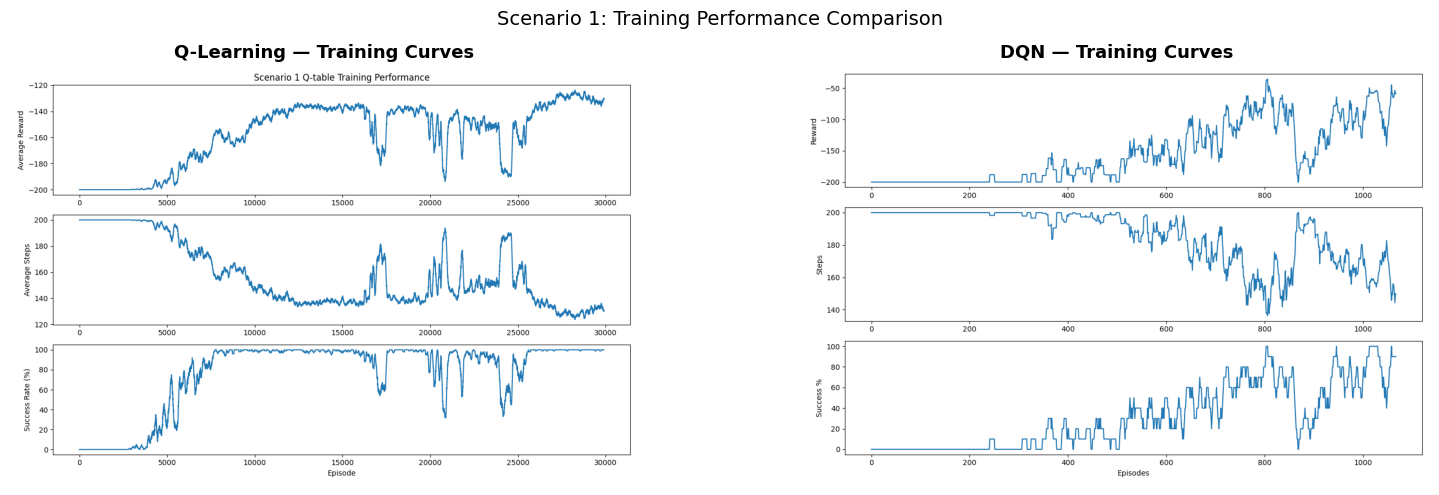

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Update to use correct path
SCENARIO1_DIR = Path("training/results/scenario1")

# Check if path exists, if not try alternate
if not SCENARIO1_DIR.exists():
    SCENARIO1_DIR = Path("results/scenario1")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qtable_img = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_qtable_training.png")
dqn_img    = mpimg.imread(SCENARIO1_DIR / "plots/scenario1_dqn_training.png")

axes[0].imshow(qtable_img)
axes[0].axis("off")
axes[0].set_title("Q-Learning — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(dqn_img)
axes[1].axis("off")
axes[1].set_title("DQN — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 1: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Visualize the Learned Q-Learning Policy Map

In this step, we load the trained **Q-table model** for Scenario 1 and visualize the policy that the agent learned.

The Q-table stores the expected value of each action for every discretized state. Since `MountainCar-v0` has a continuous state space made of **position** and **velocity**, the state space was divided into bins during training. For each position-velocity pair, the code selects the action with the highest Q-value using:



RESULTS_DIR: training/results/scenario1
MODELS_DIR: training/results/scenario1/models
Q-table shape: (40, 40, 3)
Best action map shape: (40, 40)


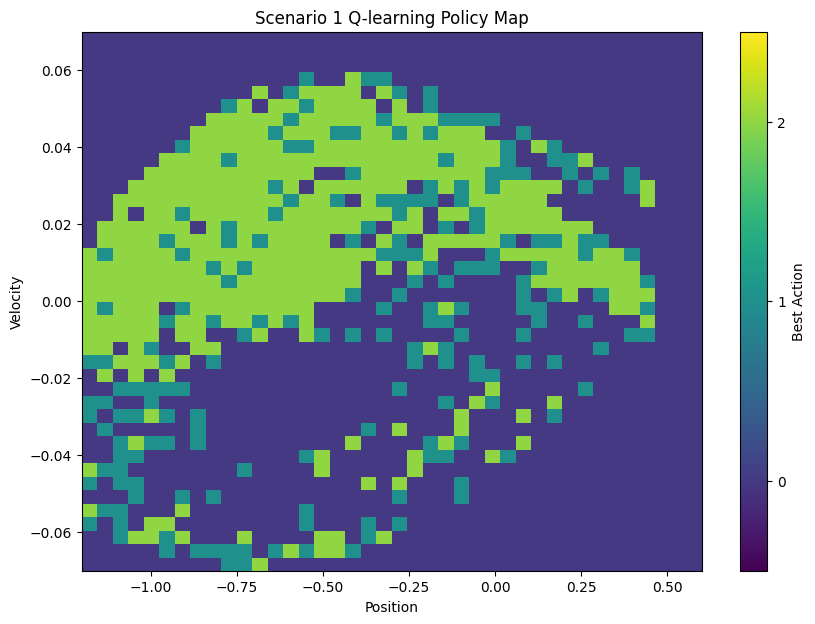

In [20]:

possible_roots = [
    Path("results/scenario1"),
    Path("training/results/scenario1"),
    Path("../results/scenario1"),
]

RESULTS_DIR = None

for path in possible_roots:
    if path.exists():
        RESULTS_DIR = path
        break

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find Scenario 1 results folder.")

MODELS_DIR = RESULTS_DIR / "models"
PLOTS_DIR = RESULTS_DIR / "plots"

print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)


# LOAD TRAINED Q-TABLE


with open(MODELS_DIR / "scenario1_qtable.pkl", "rb") as file:
    qtable_data = pickle.load(file)

q_table = qtable_data["q_table"]
position_bins = qtable_data["position_bins"]
velocity_bins = qtable_data["velocity_bins"]



# EXTRACT BEST ACTION FOR EACH STATE

best_actions = np.argmax(q_table, axis=2)

print("Q-table shape:", q_table.shape)
print("Best action map shape:", best_actions.shape)



# PLOT POLICY MAP


plt.figure(figsize=(10, 7))

plt.imshow(
    best_actions.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1],
    ],
)

plt.colorbar(ticks=[0, 1, 2], label="Best Action")
plt.clim(-0.5, 2.5)

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Policy Map")

plt.show()

### Conclusion

The Q-learning policy map shows that the agent learned a clear **momentum-based strategy** rather than simply pushing right all the time. In `MountainCar-v0`, the car cannot usually reach the goal by moving directly forward, so it must first move back and forth to build enough speed.

From the map, we can see that the best action changes depending on both **position** and **velocity**. When the car is moving in one direction, the policy often chooses actions that help increase that momentum. Then, once the car has enough speed or is in a better position

## Step 4: Why We Do Not Use a DQN Policy Map as a Main Result

For Q-learning, the policy map is directly meaningful because the model stores a **Q-table**. Each cell in the table corresponds to a discretized position-velocity state, and the best action can be read directly from that table.

For DQN, this is different. DQN does **not** store a table of actions for each state. Instead, it uses a neural network to approximate Q-values from continuous inputs. This means any DQN “policy map” must be artificially created by sampling a grid of position and velocity values and asking the model to predict an action for each point.

Because of this, the DQN policy map is only an approximation of the model’s behavior, not a direct representation of what the model stores internally. It can be useful for intuition, but it is not as clean or interpretable as the Q-learning policy map.

Therefore, in this analysis, we focus mainly on the numerical evaluation metrics and the training curves for DQN, while using the Q-learning policy map only as an interpretable visualization of the tabular method.

## Step 5: Visualize the Q-Learning Value Function

In this step, we visualize the **value function** learned by the Q-learning agent.

Instead of showing which action is selected in each state, this plot shows how valuable each position-velocity state is according to the trained Q-table. For each state, we take the maximum Q-value across all possible actions:



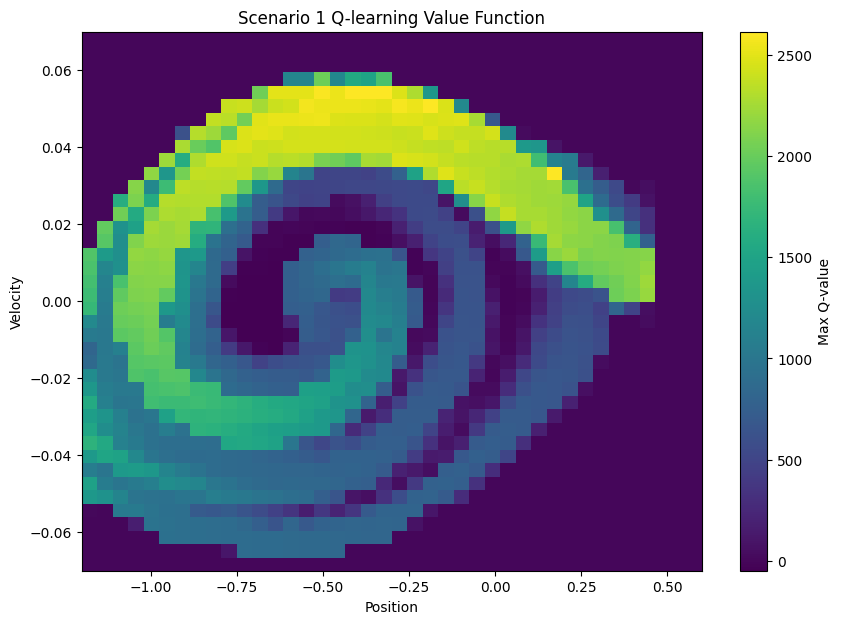

In [21]:
state_values = np.max(q_table, axis=2)

plt.figure(figsize=(10, 7))

plt.imshow(
    state_values.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(label="Max Q-value")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Value Function")

plt.show()

### Interpretation

The brighter areas show states with higher learned value, meaning the agent expects to reach the goal more easily from those position-velocity combinations. The darker areas represent lower-value states where the car is farther from success or does not have useful momentum.

The curved pattern appears because `MountainCar-v0` is a momentum-based task. The agent must move back and forth to build enough speed, so the value function depends on both **position** and **velocity**, not just how close the car is to the goal.

### Observations / Findings

The highest-value region appears near the right side of the state space, where the car is closer to the goal and has favorable velocity. Overall, the value function shows a meaningful structure, supporting that Q-learning learned an effective strategy for Scenario 1.

 Note on DQN Value Visualization

A similar value-function plot can be approximated for DQN by sampling position-velocity states and passing them through the trained neural network to obtain predicted Q-values. However, this is not as directly interpretable as the Q-learning value function, because DQN does not store explicit values for each discretized state.

Therefore, the Q-learning value map is used as a direct visualization of the tabular policy, while DQN is mainly compared through evaluation metrics and training curves.

## Step 6: Visualize Q-values for Individual Actions

In this step, we visualize the learned Q-values as 3D surfaces for specific actions.

The Q-table contains one value for each possible action in each discretized state. Since `MountainCar-v0` has three actions, the Q-table stores:

- `0`: move left
- `1`: no push
- `2`: move right

Here, we plot the Q-value surfaces for **move right** and **move left**. The x-axis represents position, the y-axis represents velocity, and the z-axis represents the learned Q-value for that action.


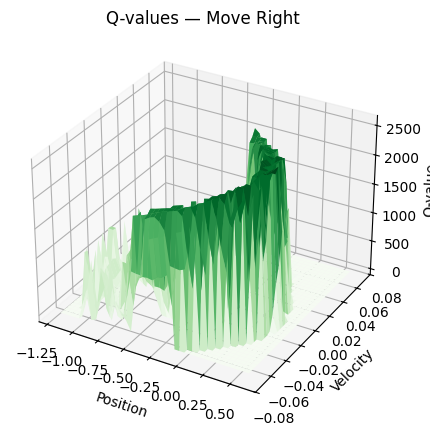

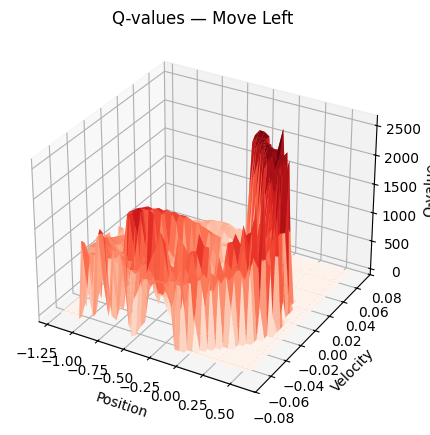

In [22]:
from mpl_toolkits.mplot3d import Axes3D

def plot_surface(Z, title, cmap):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap=cmap)

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_zlabel("Q-value")
    ax.set_title(title)

    plt.show()


# Create grid (use bins you already loaded)
X, Y = np.meshgrid(position_bins, velocity_bins)

Z_left  = q_table[:, :, 0]
Z_none  = q_table[:, :, 1]
Z_right = q_table[:, :, 2]

plot_surface(Z_right, "Q-values — Move Right", "Greens")
plot_surface(Z_left,  "Q-values — Move Left",  "Reds")

### Interpretation

The 3D surfaces show how valuable each action is in different parts of the state space. Higher peaks mean the agent expects that action to lead to better future rewards from that position and velocity.

The **move right** surface has high values in regions where the car is closer to the right hill and has useful momentum toward the goal. This shows that the agent learned when pushing right is beneficial.

The **move left** surface also has high values in certain regions, especially where moving left helps the car build backward momentum. This is important because MountainCar requires the agent to swing back before it can climb the hill.

### Observations / Findings

These plots show that Q-learning did not learn a single fixed action. Instead, it learned that the usefulness of each action depends on the current combination of **position** and **velocity**.

This supports the idea that the Q-table learned the physics of the environment: sometimes pushing left is useful for building momentum, and sometimes pushing right is useful for reaching the goal.

### Note on DQN Q-value Surfaces

A similar 3D Q-value surface could be approximated for DQN by sampling position-velocity states and passing them through the trained neural network. However, unlike Q-learning, DQN does not store explicit Q-values for each state-action pair.

For this reason, the Q-learning Q-value surfaces are more meaningful as direct visualizations of the learned table. For DQN, evaluation metrics and training curves are more reliable comparison tools because they show the model’s actual performance without relying on an artificial sampled grid.

## Step 7: Plot the Q-Learning Phase Portrait

In this step, we visualize the actual trajectories followed by the trained Q-learning agent.

A **phase portrait** plots the car’s **position** against its **velocity** over time. Instead of only looking at final evaluation metrics, this helps us understand the physical movement pattern learned by the agent.

For `MountainCar-v0`, a successful policy should not simply push right from the start. The car needs to move back and forth through the valley to build enough momentum before climbing the right hill.

Each line in the plot represents one evaluation episode with a different random seed. The legend shows how many steps the agent needed in each run.


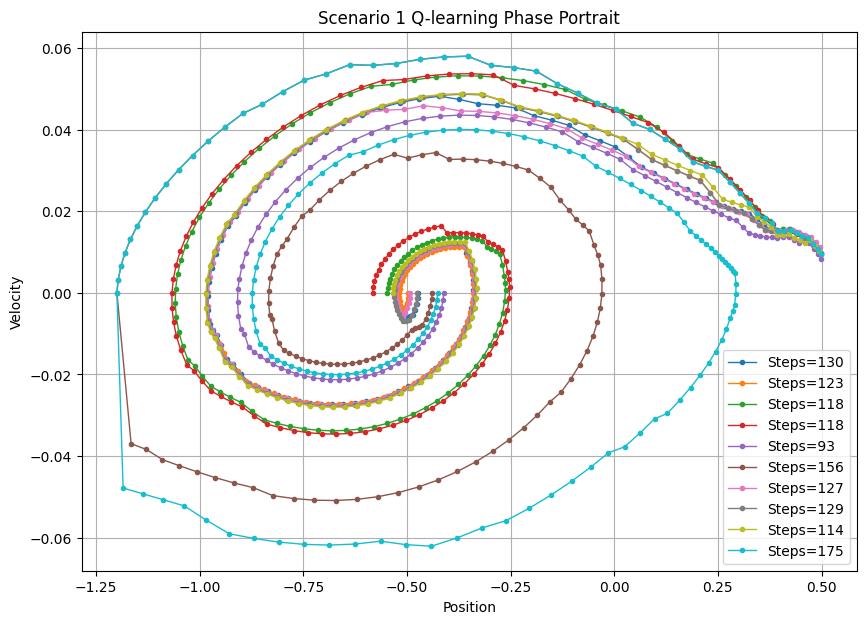

In [23]:
def discretize_state(state, position_bins, velocity_bins):
    position = state[0]
    velocity = state[1]

    position_index = np.digitize(position, position_bins) - 1
    velocity_index = np.digitize(velocity, velocity_bins) - 1

    position_index = np.clip(position_index, 0, len(position_bins) - 1)
    velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

    return position_index, velocity_index


def run_qtable_episode(q_table, position_bins, velocity_bins, seed=None):
    env = gym.make("MountainCar-v0")

    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []
    actions = []
    total_reward = 0

    for step in range(200):
        discrete_state = discretize_state(state, position_bins, velocity_bins)
        action = int(np.argmax(q_table[discrete_state]))

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "reward": total_reward,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }


plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_qtable_episode(q_table, position_bins, velocity_bins, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The trajectories form curved loops through the position-velocity space. This is expected for MountainCar because the car must swing backward and forward to gain speed.

Most trajectories first move left or downward in the phase space, then loop around and move toward the right side of the plot. This shows that the agent learned to use momentum instead of trying to go directly to the goal.

The different step counts show that some starting states are easier than others. Episodes with fewer steps reached the goal faster, while longer trajectories needed more back-and-forth movement before succeeding.

### Observations / Findings

The phase portrait confirms that the Q-learning policy learned the correct physical strategy for MountainCar. The agent uses velocity and position together, builds momentum through repeated swings, and eventually climbs toward the goal.

This supports the earlier policy map and value function results: Q-learning did not just memorize random actions, but learned a meaningful momentum-based behavior.

## Step 8: Plot the DQN Phase Portrait

In this step, we plot the phase portrait for the trained **DQN agent** in Scenario 1.

A phase portrait shows the car’s **position** against its **velocity** during an episode. This helps us understand the actual movement pattern learned by the model, not just the final numerical results.

For DQN, the action is selected using the trained neural network:


training/results/scenario1/models
[PosixPath('training/results/scenario1/models/scenario1_dqn.zip')]


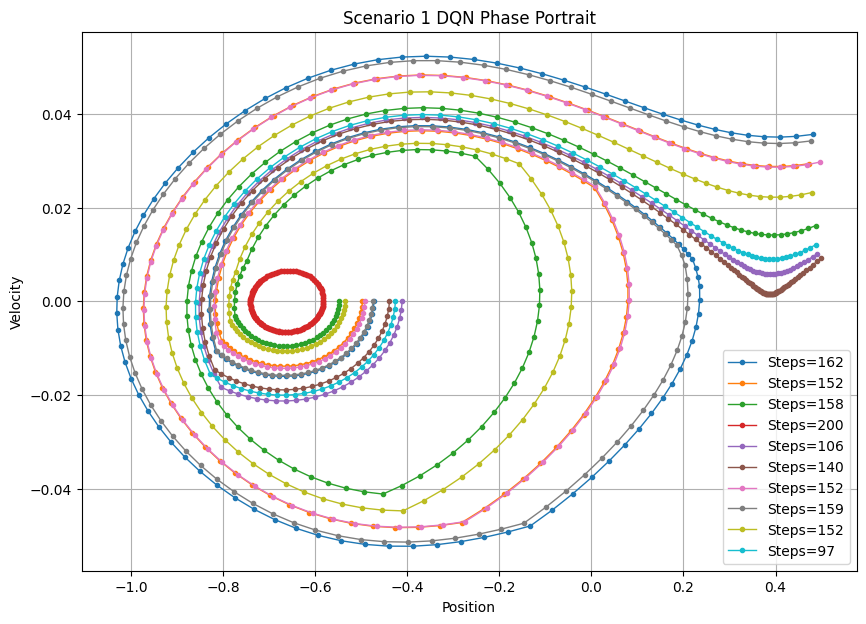

In [24]:
from pathlib import Path

BASE_DIR = Path("training/results")

METRICS_DIR = BASE_DIR / "scenario1" / "metrics"
MODELS_DIR  = BASE_DIR / "scenario1" / "models"
PLOTS_DIR   = BASE_DIR / "scenario1" / "plots"

print(MODELS_DIR)
print(list(MODELS_DIR.glob("scenario1_dqn*")))

dqn_model = DQN.load(MODELS_DIR / "scenario1_dqn")


def run_dqn_episode(model, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []
    actions = []
    total_reward = 0

    for step in range(200):
        action, _ = model.predict(state, deterministic=True)
        action = int(action)

        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)

        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "reward": total_reward,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }


plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_dqn_episode(dqn_model, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 DQN Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation

The DQN trajectories show that the agent learned the general `MountainCar-v0` strategy: it moves back and forth through the valley to build momentum before trying to climb the right hill.

However, the DQN results are less consistent than Q-learning. Some episodes finish quickly, such as the run with **97 steps**, while others take much longer, including one episode that reaches the maximum limit of **200 steps**. This matches the metric table, where DQN had a lower success rate and a higher average number of steps.

### Comparison with Q-learning

Compared to the Q-learning phase portrait, the DQN phase portrait shows more variability between episodes. Q-learning produces more consistently successful trajectories, while DQN sometimes follows longer loops before reaching the goal or fails to finish within the time limit.

Overall, this supports the conclusion that **Q-learning is more reliable in Scenario 1**. Since the environment is simple and discrete, the Q-table can learn more precise state-action decisions. DQN still learns the correct momentum-based behavior, but its neural network approximation makes the policy less stable across different starting states.

## Step 9: Q-Learning State Visitation Map

In this step, we count how often the trained Q-learning agent visits each position-velocity region over 100 episodes.

The heatmap shows the parts of the state space that the agent uses most often while following its learned policy. Brighter areas mean that those states were visited more frequently.

### Interpretation

The visited states form a spiral-like path, which matches the expected MountainCar behavior. The agent repeatedly moves through the valley to build momentum before climbing toward the goal.

The brightest areas show the most common parts of the trajectory, especially around the central valley and near the final climb. This confirms that the Q-learning agent follows a consistent momentum-building strategy instead of moving randomly through the state space.

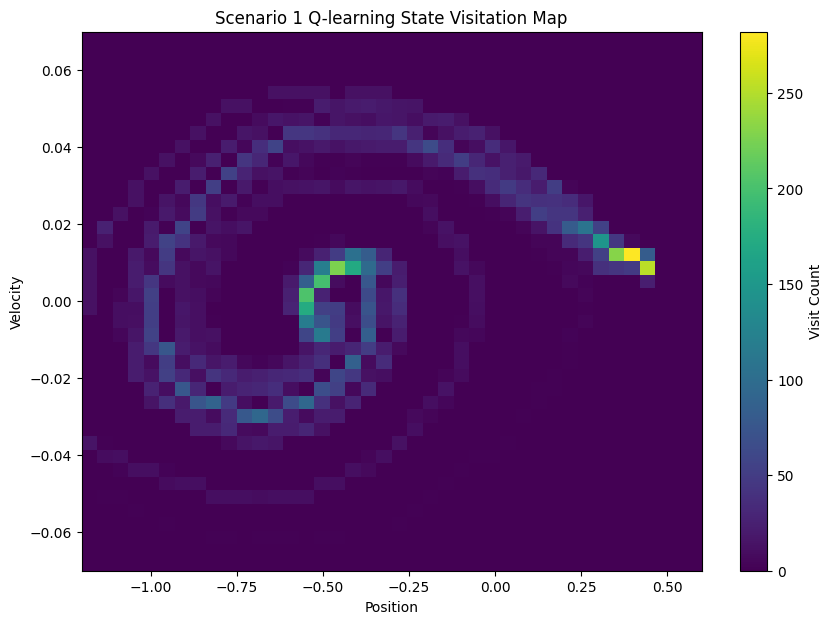

In [25]:
visit_counts = np.zeros((len(position_bins), len(velocity_bins)))

for seed in range(100):
    episode = run_qtable_episode(q_table, position_bins, velocity_bins, seed=seed)

    for position, velocity in zip(episode["positions"], episode["velocities"]):
        position_index = np.digitize(position, position_bins) - 1
        velocity_index = np.digitize(velocity, velocity_bins) - 1

        position_index = np.clip(position_index, 0, len(position_bins) - 1)
        velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

        visit_counts[position_index, velocity_index] += 1

plt.figure(figsize=(10, 7))

plt.imshow(
    visit_counts.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)

plt.colorbar(label="Visit Count")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 1 Q-learning State Visitation Map")

plt.show()

Note on DQN Visualizations

DQN is less directly visualizable because it does not store one value per state-action pair. Instead, it uses a neural network to approximate Q-values from continuous inputs. Any DQN policy map or value map would have to be created by manually sampling a grid of states and asking the model for predictions, so it is only an approximation of the model’s behavior.

Because of this, the DQN analysis is less interpretable than the Q-learning analysis. However, we still included the most meaningful visual comparisons possible, especially the training curves and phase portrait, which show how the DQN agent actually behaves during evaluation.

### Scenario 1 Interpretation and Conclusion

In Scenario 1, **Q-learning performed better than DQN** because `MountainCar-v0` is a simple, low-dimensional environment that can be discretized effectively. The Q-table directly stores values for each position-velocity bin and action, which makes the policy stable and easy to interpret.

The policy map, value function, visitation map, and phase portrait all show that Q-learning learned the correct MountainCar strategy: the car does not simply push right, but moves back and forth to build momentum before climbing the right hill.

DQN also learned part of this behavior, but its results were less consistent. Since DQN uses a neural network to approximate Q-values, it is less interpretable and can be noisier in small environments where a Q-table is already enough.

Overall, this scenario shows that **deep RL is not always the best choice**. For small discrete or easily discretized problems, tabular Q-learning can be simpler, more reliable, and more interpretable.

## Scenario 2 — Continuous MountainCar: Minimum Fuel

**Environment**: `MountainCarContinuous-v0` · **Objective**: Reach the goal while minimizing fuel usage

---

In the second scenario, we move to the continuous version of the environment. Unlike the discrete version where actions are fixed steps, the continuous car can apply a variable amount of force between **-1.0 and +1.0**. The objective is shifted from speed to **efficiency**: the agent is penalized by the **square of the action** at every timestep.

This creates a different challenge: the agent must still build momentum, but it must do so using as little force as possible. "Flooring it" is no longer the optimal strategy. This scenario tests whether continuous control algorithms can balance the physics of the mountain with a cost-sensitive objective.

### Algorithms

**SAC (Soft Actor-Critic)** is an off-policy actor-critic algorithm that uses **entropy regularization**. It maximizes a trade-off between expected reward and entropy, encouraging exploration and robust policies. For the fuel-minimization task, SAC's stochastic nature and entropy bonus are theoretically useful for discovering efficient paths, as it naturally tries to avoid high-magnitude actions unless they are necessary for the long-term goal.

**TD3 (Twin Delayed DDPG)** is a deterministic actor-critic algorithm. It improves upon DDPG by using twin critics to reduce overestimation bias and delayed policy updates to improve stability. TD3 is often more sample-efficient than SAC in stable environments, but its deterministic policy might lead to less exploration in the sparse-reward valley of MountainCar.

Both algorithms were trained for **300,000 timesteps** using enhanced reward shaping that rewards progress (change in position) and velocity, while penalizing fuel usage. Evaluation is performed on the standard environment to measure true fuel efficiency.

## Step 1: Load and Compare Scenario 2 Results

In this first step, we load the saved evaluation metrics for **Scenario 2: Continuous MountainCar - Minimum Fuel**.

The goal of this scenario is to compare two continuous-control algorithms:

- **Soft Actor-Critic (SAC)**
- **Twin Delayed DDPG (TD3)**

Both agents were trained on `MountainCarContinuous-v0`, where the car must still build momentum to reach the goal, but now every action also has a fuel penalty. This changes the question from *can the agent reach the flag?* to *can the agent reach the flag efficiently?*

The evaluation results show that **TD3 clearly outperformed SAC in Scenario 2**. TD3 reached a **100% success rate**, while SAC reached **0%**. TD3 also needed far fewer steps on average, about **65.8 steps** compared with SAC's **999**, which means SAC timed out in every evaluation episode.

The reward values reinforce the same conclusion. TD3 achieved a strongly positive average reward of **93.55**, while SAC stayed near **-5.02**. Since the continuous environment rewards success but subtracts a fuel penalty, this means TD3 found trajectories that actually solved the task, whereas SAC improved its shaped training behavior without learning a policy that consistently escaped the valley.

The raw fuel numbers need a small caution in interpretation. **SAC appears to use less fuel on average**, but that is mainly because it never reaches the goal and often applies weaker actions for 999 ineffective steps. **TD3 uses slightly more force overall, but converts that force into successful, short trajectories**, which is the behavior that actually matches the scenario objective.

TD3 was also faster to train, taking about **748.93 seconds**, while SAC needed about **1363.06 seconds**.

Overall, these results suggest that for this continuous, fuel-aware version of MountainCar, **TD3 was both more reliable and more practical**. It discovered a stable momentum-building strategy within the training budget, while SAC remained stuck in a non-solving regime.

**Finding**: In this **continuous control** setting, the deterministic policy learned by **TD3** was better aligned with the task than SAC's stochastic policy. TD3 found a repeatable momentum-building solution; SAC did not convert exploration into goal-reaching behavior.

In [26]:
import json
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stable_baselines3 import SAC, TD3

SCENARIO2_DIR = Path("training/results/scenario2")

if not SCENARIO2_DIR.exists():
    SCENARIO2_DIR = Path("results/scenario2")
    if not SCENARIO2_DIR.exists():
        print("Error: Scenario 2 results not found.")
        print("Run the training scripts first:")
        print("  python training/scenario2_sac.py")
        print("  python training/scenario2_td3.py")
        raise FileNotFoundError(f"No results found at {SCENARIO2_DIR}")

METRICS_DIR_2 = SCENARIO2_DIR / "metrics"

with open(METRICS_DIR_2 / "scenario2_sac.json") as f:
    sac_metrics = json.load(f)

with open(METRICS_DIR_2 / "scenario2_td3.json") as f:
    td3_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)", "success_rate_percent"),
    ("Avg Reward", "average_reward"),
    ("Avg Steps", "average_steps"),
    ("Avg Fuel", "average_fuel"),
    ("Min Steps", "min_steps"),
    ("Max Steps", "max_steps"),
    ("Training Time (s)", "training_time_seconds"),
]

comparison_rows = []
for label, key in metrics_to_show:
    comparison_rows.append(
        {
            "Metric": label,
            "SAC": sac_metrics.get(key, "N/A"),
            "TD3": td3_metrics.get(key, "N/A"),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("Metric")

print("=" * 62)
print("SCENARIO 2: Continuous MountainCar - Minimum Fuel")
print("=" * 62)
print(f"{'Metric':<25} {'SAC':>15} {'TD3':>15}")
print("-" * 62)
for label, key in metrics_to_show:
    sac_value = sac_metrics.get(key, "N/A")
    td3_value = td3_metrics.get(key, "N/A")
    if isinstance(sac_value, float):
        print(f"{label:<25} {sac_value:>15.2f} {td3_value:>15.2f}")
    else:
        print(f"{label:<25} {str(sac_value):>15} {str(td3_value):>15}")
print("=" * 62)

if td3_metrics["average_steps"] > 0:
    speedup = sac_metrics["average_steps"] / td3_metrics["average_steps"]
    print(f"TD3 reaches the goal about {speedup:.1f}x faster than SAC's timeout baseline.")
print("Note: SAC's lower raw fuel cost is misleading because it never solves the task.")
print("A fuel-efficient policy must still reach the flag consistently.")

comparison_df.round(2)

SCENARIO 2: Continuous MountainCar - Minimum Fuel
Metric                                SAC             TD3
--------------------------------------------------------------
Success Rate (%)                     0.00          100.00
Avg Reward                          -5.02           93.55
Avg Steps                          999.00           65.80
Avg Fuel                            50.17           64.51
Min Steps                             999              65
Max Steps                             999              67
Training Time (s)                 1363.06          748.93
TD3 reaches the goal about 15.2x faster than SAC's timeout baseline.
Note: SAC's lower raw fuel cost is misleading because it never solves the task.
A fuel-efficient policy must still reach the flag consistently.


,SAC,TD3
Metric,,
Success Rate (%),0.00,100.00
Avg Reward,-5.02,93.55
Avg Steps,999.00,65.80
Avg Fuel,50.17,64.51
Min Steps,999.00,65.00
Max Steps,999.00,67.00
Training Time (s),1363.06,748.93


## Step 2: Visualize Scenario 2 Training Curves

In this step, we load and display the saved training plots for **Scenario 2: Continuous MountainCar - Minimum Fuel**.

The figure compares the learning behavior of:

- **SAC**, shown on the left
- **TD3**, shown on the right

Each plot contains two training curves:

- **Reward**: shows whether the policy is improving under the shaped training objective
- **Steps**: shows whether the agent is learning to finish episodes more quickly

The training curves reveal an important difference between **appearing to improve** and **actually learning to solve the task**.

For **SAC**, the average training reward rises from strongly negative values to mildly positive values, which means the agent is learning something under the shaped reward. However, the average episode length stays flat at **999 steps** throughout training. That means SAC never leaves the timeout regime. In other words, the reward shaping helps SAC improve local behavior, but not enough to produce a successful end-to-end solution.

For **TD3**, the curves show a much cleaner learning transition. Reward rises sharply early in training and then stabilizes at a high level, while the average number of steps collapses from nearly **1000** to roughly **70** and stays there. This is exactly what we would want in a minimum-fuel scenario: the policy becomes both successful and stable.

Overall, the training curves suggest that **TD3 learns faster and converges more reliably**, while **SAC plateaus in a partially improved but still unsuccessful regime**.

**Finding**: TD3 does not just finish with better metrics; it shows a much stronger training signal of real convergence. SAC's reward curve alone would look promising, but the flat step curve reveals that it never actually solves the environment.

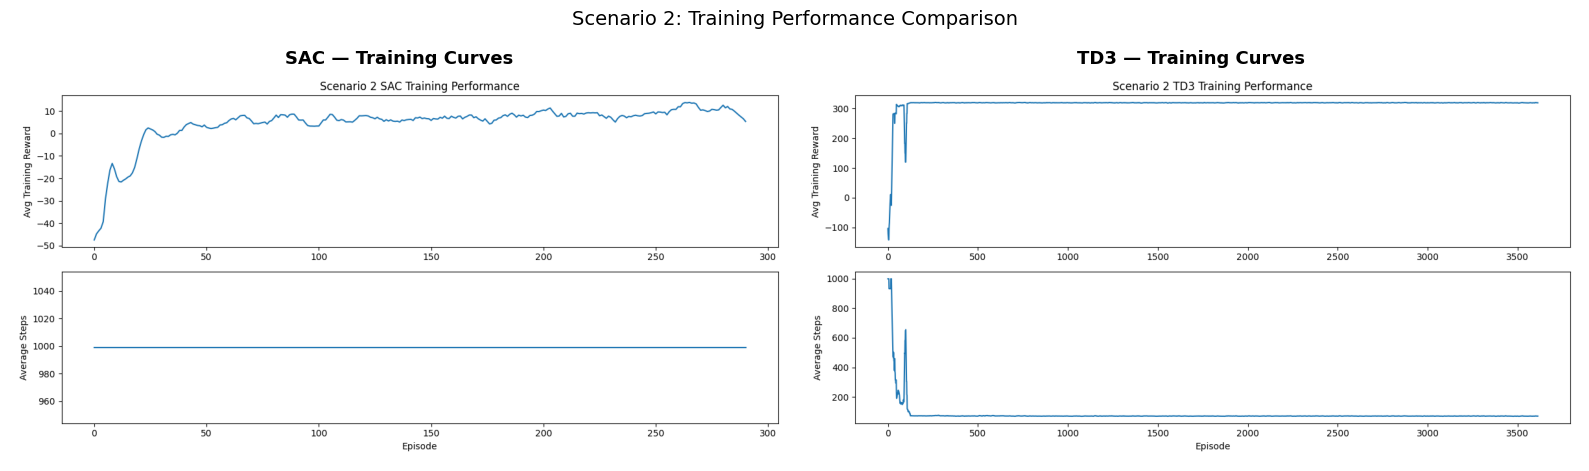

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sac_plot_path = SCENARIO2_DIR / "plots" / "scenario2_sac_training.png"
td3_plot_path = SCENARIO2_DIR / "plots" / "scenario2_td3_training.png"

if not sac_plot_path.exists() or not td3_plot_path.exists():
    raise FileNotFoundError("Scenario 2 training plots were not found in the saved results folder.")

img_sac = plt.imread(sac_plot_path)
img_td3 = plt.imread(td3_plot_path)

axes[0].imshow(img_sac)
axes[0].axis("off")
axes[0].set_title("SAC — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(img_td3)
axes[1].axis("off")
axes[1].set_title("TD3 — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 2: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3: Plot Phase Portraits and Action Profiles

In this step, we visualize the behavior of the trained continuous-control agents by running evaluation episodes and plotting their trajectories in the **position-velocity phase space**.

For Scenario 2, these behavior plots are especially important because the numerical metrics alone do not show *how* the agent is using force. A successful policy should:

- build momentum by oscillating through the valley
- time the final climb correctly
- avoid wasting fuel through unnecessary large actions

Unlike the Q-table analysis in Scenario 1, SAC and TD3 do not expose an interpretable table of values for each state. Because of that, the most meaningful behavioral visuals here are:

- **phase portraits**, which show whether the car learns the correct momentum-building motion
- **action traces**, which show whether the controller uses force in a deliberate and fuel-aware way

Each line corresponds to one deterministic rollout from a different random seed.

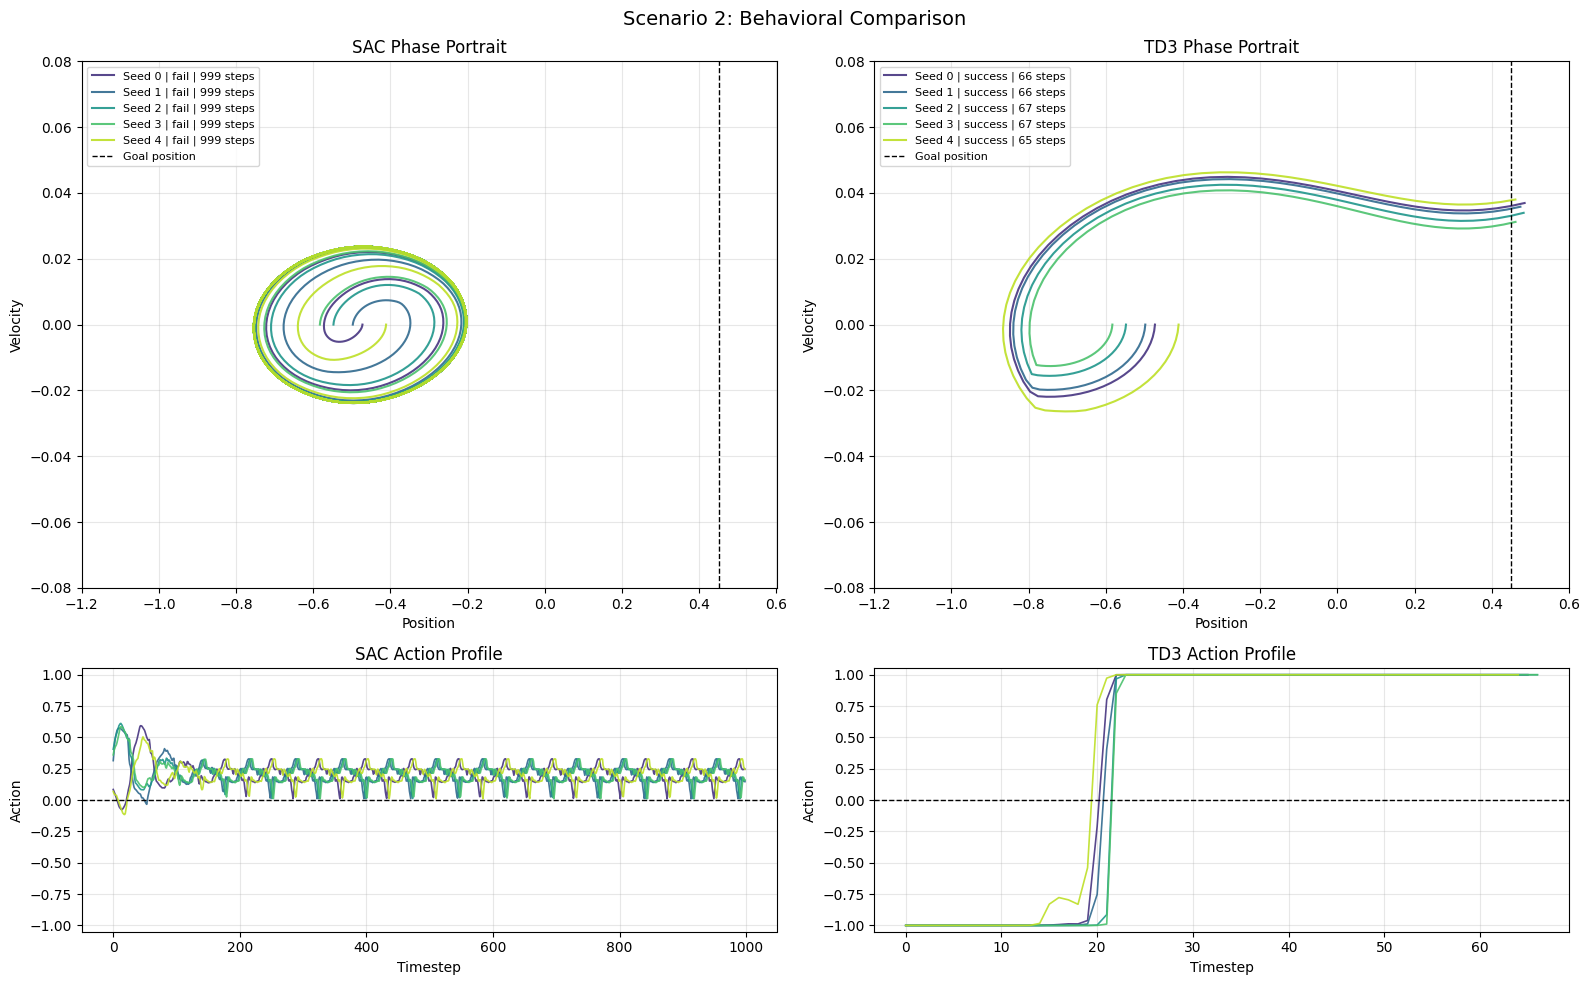

Behavior summary over 5 deterministic rollouts:


,Successes / 5,Avg Steps,Avg Fuel Proxy,Avg |Action|,Avg Max Position
Algorithm,,,,,
SAC,0,999.0,50.14,0.21,-0.20
TD3,5,66.2,65.02,0.99,0.47


In [28]:
def run_continuous_episode(model, env_name="MountainCarContinuous-v0", max_steps=999, seed=None):
    env = gym.make(env_name)
    state, _ = env.reset(seed=seed)

    positions = [float(state[0])]
    velocities = [float(state[1])]
    actions = []
    rewards = []

    for _ in range(max_steps):
        action, _ = model.predict(state, deterministic=True)
        action_array = np.asarray(action, dtype=np.float32).reshape(-1)

        next_state, reward, terminated, truncated, _ = env.step(action_array)

        actions.append(float(action_array[0]))
        rewards.append(float(reward))
        positions.append(float(next_state[0]))
        velocities.append(float(next_state[1]))

        state = next_state

        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "rewards": rewards,
        "steps": len(actions),
        "fuel_used": float(np.sum(np.square(actions))),
        "avg_abs_action": float(np.mean(np.abs(actions))) if actions else 0.0,
        "max_position": float(np.max(positions)) if positions else float("nan"),
        "success": bool(positions[-1] >= 0.45) if positions else False,
    }


MODELS_DIR_2 = SCENARIO2_DIR / "models"
sac_model = SAC.load(MODELS_DIR_2 / "scenario2_sac")
td3_model = TD3.load(MODELS_DIR_2 / "scenario2_td3")

seeds = list(range(5))
episodes_by_algorithm = {
    "SAC": [run_continuous_episode(sac_model, seed=seed) for seed in seeds],
    "TD3": [run_continuous_episode(td3_model, seed=seed) for seed in seeds],
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={"height_ratios": [2, 1]})
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(seeds)))

goal_position = 0.45

for column, algorithm in enumerate(["SAC", "TD3"]):
    phase_ax = axes[0, column]
    action_ax = axes[1, column]

    for color, seed, episode in zip(colors, seeds, episodes_by_algorithm[algorithm]):
        outcome = "success" if episode["success"] else "fail"
        phase_ax.plot(
            episode["positions"],
            episode["velocities"],
            color=color,
            linewidth=1.5,
            alpha=0.9,
            label=f"Seed {seed} | {outcome} | {episode['steps']} steps",
        )
        action_ax.plot(
            episode["actions"],
            color=color,
            linewidth=1.2,
            alpha=0.9,
            label=f"Seed {seed}",
        )

    phase_ax.axvline(goal_position, color="black", linestyle="--", linewidth=1, label="Goal position")
    phase_ax.set_xlim(-1.2, 0.6)
    phase_ax.set_ylim(-0.08, 0.08)
    phase_ax.set_xlabel("Position")
    phase_ax.set_ylabel("Velocity")
    phase_ax.set_title(f"{algorithm} Phase Portrait")
    phase_ax.grid(True, alpha=0.3)
    phase_ax.legend(fontsize=8, loc="best")

    action_ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    action_ax.set_ylim(-1.05, 1.05)
    action_ax.set_xlabel("Timestep")
    action_ax.set_ylabel("Action")
    action_ax.set_title(f"{algorithm} Action Profile")
    action_ax.grid(True, alpha=0.3)

plt.suptitle("Scenario 2: Behavioral Comparison", fontsize=14)
plt.tight_layout()
plt.show()

behavior_rows = []
for algorithm, episodes in episodes_by_algorithm.items():
    behavior_rows.append(
        {
            "Algorithm": algorithm,
            "Successes / 5": sum(episode["success"] for episode in episodes),
            "Avg Steps": np.mean([episode["steps"] for episode in episodes]),
            "Avg Fuel Proxy": np.mean([episode["fuel_used"] for episode in episodes]),
            "Avg |Action|": np.mean([episode["avg_abs_action"] for episode in episodes]),
            "Avg Max Position": np.mean([episode["max_position"] for episode in episodes]),
        }
    )

print("Behavior summary over 5 deterministic rollouts:")
pd.DataFrame(behavior_rows).set_index("Algorithm").round(2)

### Scenario 2 Interpretation and Conclusion

In Scenario 2, **TD3 was clearly the stronger algorithm**. It solved the continuous MountainCar task with **100% reliability**, reached the goal in a tightly concentrated **65-67 step** band, and converged faster during training. Both the metric table and the training curves point to the same result: TD3 found a stable policy and kept it.

The behavior plots explain *why* the final metrics look so different. **TD3's phase portraits** show clean oscillatory loops that progressively build momentum and then transition into a successful climb. Its **action profiles** are decisive and structured, which is exactly what this environment requires: apply force when it matters, then cash that momentum into a short successful episode.

**SAC**, by contrast, improved under the shaped reward without learning the full task. Its reward curve rises, but the step curve remains flat at the timeout limit, and its trajectories stay trapped in ineffective oscillations. This is a good example of why training reward alone is not enough for interpretation.

A final nuance is that **lower raw fuel usage does not automatically mean better fuel efficiency**. SAC uses less force overall, but only because it never reaches the goal. TD3 spends slightly more fuel, yet does so in service of consistently solving the problem in a short horizon. For this scenario, that is the more meaningful notion of efficiency.

Overall, Scenario 2 shows that for **continuous MountainCar with a fuel-sensitive objective**, **TD3's deterministic and stable control** was much better suited to the problem than SAC's entropy-regularized exploration.

## Scenario 3 — Discrete MountainCar: Minimum Fuel

**Environment**: MountainCar-v0  
**Objective**: Reach the goal while minimizing fuel usage (non-neutral actions)

Scenario 3 uses the same discrete MountainCar environment as Scenario 1, but with a different objective. Instead of minimizing steps, the goal is to **minimize fuel consumption** while still reaching the flag.

**Algorithms**:
- Q-Learning with Q-table
- Deep Q-Network (DQN)

Both algorithms use shaped rewards that include a **fuel penalty** for non-neutral actions, encouraging the agent to learn conservative, fuel-efficient policies.

## Hyperparameters

Both algorithms were trained with shaped rewards including:
- Base penalty: -1 per step
- Progress bonus: 100.0 × (position change)
- Velocity bonus: 10.0 × |velocity|
- **Fuel penalty**: -0.001 per non-neutral action
- Goal bonus: +100 for reaching the flag

**Q-Learning**:
- Training episodes: 30,000
- State discretization: 30×30 bins (position × velocity)
- Learning rate (α): 0.2
- Discount factor (γ): 0.99
- Epsilon decay: 1.0 → 0.01 at rate 0.9997 per episode
- Max steps per episode: 200

**DQN**:
- Training timesteps: 500,000
- Network: MLP [128, 128]
- Learning rate: 0.001
- Replay buffer: 100,000
- Batch size: 64
- Target network update: every 1,000 steps
- Exploration: 1.0 → 0.02 over 40% of training
- Max steps per episode: 200

Both use seed 42 for reproducibility.

In [29]:
# Step 1: Load and Compare Scenario 3 Results

METRICS_DIR = Path("training/results/scenario3/metrics")

# Check if path exists, if not try alternate location
if not METRICS_DIR.exists():
    METRICS_DIR = Path("results/scenario3/metrics")
    if not METRICS_DIR.exists():
        print("❌ Error: Results not found!")
        print("Make sure you've run the training scripts first:")
        print("  python training/scenario3_qlearning.py")
        print("  python training/scenario3_dqn.py")
        raise FileNotFoundError(f"No results found at {METRICS_DIR}")

with open(METRICS_DIR / "scenario3_qtable.json") as f:
    qtable_metrics = json.load(f)

with open(METRICS_DIR / "scenario3_dqn.json") as f:
    dqn_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)", "success_rate_percent"),
    ("Avg Reward", "average_reward"),
    ("Avg Steps", "average_steps"),
    ("Avg Fuel", "average_fuel"),
    ("Min Steps", "min_steps"),
    ("Max Steps", "max_steps"),
    ("Training Time (s)", "training_time_seconds"),
]

print("=" * 57)
print("SCENARIO 3: Discrete MountainCar - Minimum Fuel")
print("=" * 57)
print(f"{'Metric':<25} {'Q-Learning':>15} {'DQN':>15}")
print("-" * 57)

for label, key in metrics_to_show:
    q_val = qtable_metrics.get(key, "N/A")
    d_val = dqn_metrics.get(key, "N/A")
    if isinstance(q_val, float):
        print(f"{label:<25} {q_val:>15.2f} {d_val:>15.2f}")
    else:
        print(f"{label:<25} {str(q_val):>15} {str(d_val):>15}")

print("=" * 57)

SCENARIO 3: Discrete MountainCar - Minimum Fuel
Metric                         Q-Learning             DQN
---------------------------------------------------------
Success Rate (%)                    72.00           41.00
Avg Reward                          11.61          -46.13
Avg Steps                          163.01          181.64
Avg Fuel                           145.55          175.92
Min Steps                             125             150
Max Steps                             200             200
Training Time (s)                   82.18          124.46


The evaluation results show a significant performance difference between Q-Learning and DQN in Scenario 3:

**Success Rate**: Q-Learning achieved a 72% success rate, while DQN only reached 41%. This means Q-Learning successfully reached the goal almost twice as often as DQN.

**Fuel Efficiency**: Q-Learning used an average of 145.55 non-neutral actions, compared to DQN's 175.92. This means Q-Learning was more fuel-efficient by approximately 30 actions per episode.

**Reward**: Q-Learning achieved a positive average reward of +11.61, while DQN had a negative average reward of -46.13. Since the reward function penalizes fuel usage and time spent, this large difference indicates that DQN struggled significantly with the fuel minimization objective.

**Steps**: Q-Learning reached the goal in an average of 163.01 steps, while DQN took 181.64 steps. Q-Learning was faster, though both are well below the 200-step limit when successful.

**Training Time**: Q-Learning trained in 82.18 seconds, while DQN took 124.46 seconds, making Q-Learning faster to train.

**Overall Finding**: Q-Learning clearly outperformed DQN in Scenario 3. The combination of higher success rate and lower fuel usage shows that the tabular Q-Learning method was better able to learn the fuel-efficient policy. DQN's lower success rate and higher fuel consumption suggest it struggled to balance the competing objectives of reaching the goal while minimizing actions.

## Step 2: Visualize Scenario 3 Training Curves

In this step, we load and display the saved training plots for Scenario 3: Discrete MountainCar - Minimum Fuel.

The figure compares the learning behavior of:
- Q-Learning, shown on the left
- DQN, shown on the right

Each plot contains training curves showing how the agent's performance evolved during training.

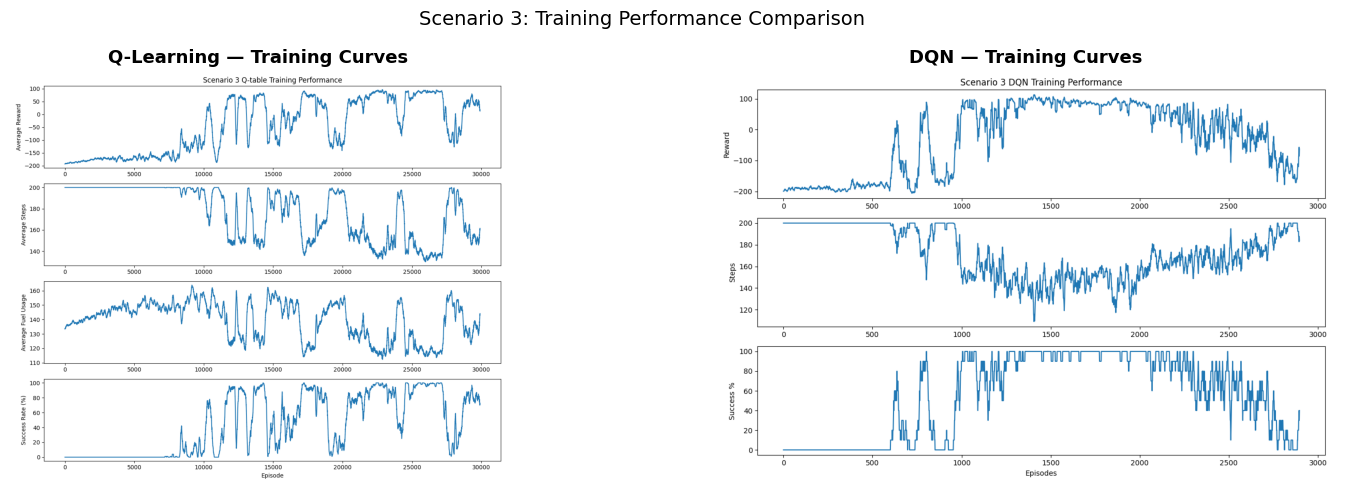

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

# Update to use correct path
SCENARIO3_DIR = Path("training/results/scenario3")

# Check if path exists, if not try alternate
if not SCENARIO3_DIR.exists():
    SCENARIO3_DIR = Path("results/scenario3")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

qtable_img = mpimg.imread(SCENARIO3_DIR / "plots/scenario3_qtable_training.png")
dqn_img = mpimg.imread(SCENARIO3_DIR / "plots/scenario3_dqn_training.png")

axes[0].imshow(qtable_img)
axes[0].axis("off")
axes[0].set_title("Q-Learning — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(dqn_img)
axes[1].axis("off")
axes[1].set_title("DQN — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 3: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()

From the training curves, we can see the learning behavior of both algorithms:

**Q-Learning (Left)**:
- Average Reward: Starts around -200 and improves to fluctuate between roughly -50 to +100, with high variability throughout training
- Average Steps: Starts around 200 and gradually decreases, fluctuating mostly between 120-180 steps
- Average Fuel Usage: Shows fluctuations between roughly 120-160 throughout training
- Success Rate: Starts near 0%, climbs and fluctuates between roughly 60-100% for much of training, with periodic drops

**DQN (Right)**:
- Reward: Starts around -200, improves to peak around +50-100 in the middle portion of training (around episodes 500-1500), but then declines and ends around -100 to -200
- Steps: Highly variable throughout, ranging between roughly 120-200 steps with no clear stable pattern
- Success Rate: Very unstable, showing brief peaks up to ~100% but frequently dropping to 0-20%, particularly unstable in the latter half of training

**Key Observation**: Both algorithms show noisy training, but Q-Learning maintains relatively higher performance in the later stages, while DQN shows what appears to be performance collapse in the second half of training, with success rate dropping significantly toward the end.

## Step 3: Visualize the Learned Q-Learning Policy Map

In this step, we load the trained Q-table model for Scenario 3 and visualize the policy that the agent learned.

The Q-table stores the expected value of each action for every discretized state. Since MountainCar-v0 has a continuous state space made of position and velocity, the state space was divided into bins during training. For each position-velocity pair, the code selects the action with the highest Q-value using `np.argmax(q_table[state])`.

The policy map shows which action (0=left, 1=neutral, 2=right) the agent prefers in each region of the state space.

RESULTS_DIR: training/results/scenario3
MODELS_DIR: training/results/scenario3/models
Q-table shape: (30, 30, 3)
Best action map shape: (30, 30)


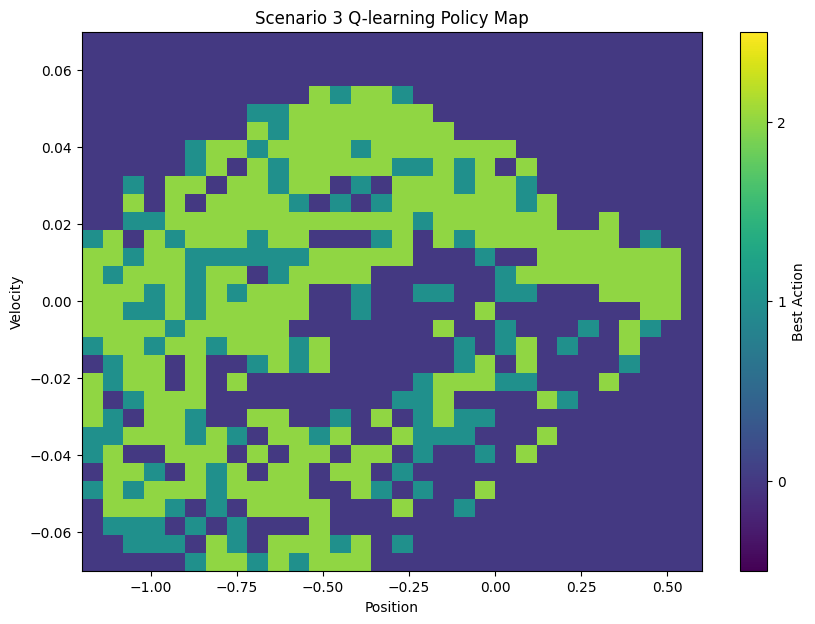

In [31]:
possible_roots = [
    Path("results/scenario3"),
    Path("training/results/scenario3"),
    Path("../results/scenario3"),
]

RESULTS_DIR = None
for path in possible_roots:
    if path.exists():
        RESULTS_DIR = path
        break

if RESULTS_DIR is None:
    raise FileNotFoundError("Could not find Scenario 3 results folder.")

MODELS_DIR = RESULTS_DIR / "models"
PLOTS_DIR = RESULTS_DIR / "plots"

print("RESULTS_DIR:", RESULTS_DIR)
print("MODELS_DIR:", MODELS_DIR)

# LOAD TRAINED Q-TABLE
with open(MODELS_DIR / "scenario3_qtable.pkl", "rb") as file:
    qtable_data = pickle.load(file)

q_table = qtable_data["q_table"]
state_low = qtable_data["state_low"]
state_high = qtable_data["state_high"]
bins = qtable_data["bins"]

# Create bin edges for visualization
position_bins = np.linspace(state_low[0], state_high[0], bins[0] + 1)
velocity_bins = np.linspace(state_low[1], state_high[1], bins[1] + 1)

# EXTRACT BEST ACTION FOR EACH STATE
best_actions = np.argmax(q_table, axis=2)

print("Q-table shape:", q_table.shape)
print("Best action map shape:", best_actions.shape)

# PLOT POLICY MAP
plt.figure(figsize=(10, 7))
plt.imshow(
    best_actions.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1],
    ],
)
plt.colorbar(ticks=[0, 1, 2], label="Best Action")
plt.clim(-0.5, 2.5)
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 3 Q-learning Policy Map")
plt.show()

The Q-learning policy map shows the best action selected by the agent in each position-velocity state:
- **Dark purple (0)**: Push left
- **Teal/cyan (1)**: Neutral/no push
- **Yellow/bright green (2)**: Push right

**Observations**:

The policy shows a mixed strategy with all three actions appearing across the state space:

- **Yellow/bright green (action 2 - push right)**: Prominent in the upper portion (positive velocities around 0.04-0.06) and scattered on the left side. These states benefit from pushing right to build momentum or make the final climb.

- **Dark purple (action 0 - push left)**: Concentrated in center and right portions, particularly around zero velocity. Represents the backward swing needed to build momentum.

- **Teal/cyan (action 1 - neutral)**: Scattered throughout, particularly on the right side. States where the agent learned it can coast without using fuel.

**Impact of Fuel Minimization**:

The policy learned the momentum-based strategy for MountainCar, using left pushes (build backward momentum), right pushes (climb), and neutral actions (conserve fuel when momentum is sufficient).

The presence of neutral actions shows the influence of the **fuel penalty** (−0.001 per non-neutral action). The agent learned to save fuel by coasting when possible, rather than constantly applying thrust. This differs from a pure speed-minimization objective where the agent would use actions more aggressively.

## Step 4: Visualize the Q-Learning Value Function

In this step, we visualize the value function learned by the Q-learning agent.

Instead of showing which action is selected in each state, this plot shows how valuable each position-velocity state is according to the trained Q-table. For each state, we take the maximum Q-value across all possible actions:

`state_values = np.max(q_table, axis=2)`

This represents the expected cumulative return the agent can achieve starting from that state, following the learned policy.

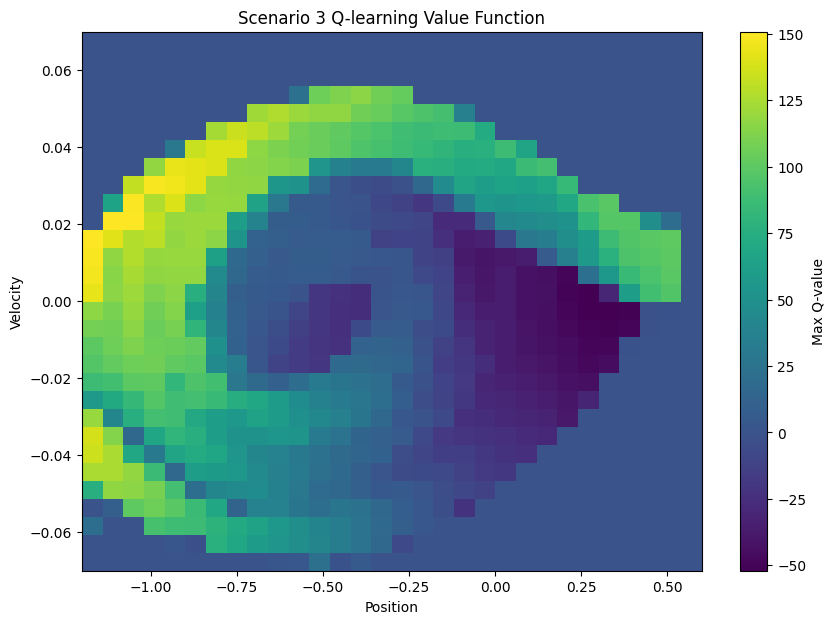

In [32]:
# Calculate state values (max Q-value across actions for each state)
state_values = np.max(q_table, axis=2)

plt.figure(figsize=(10, 7))
plt.imshow(
    state_values.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)
plt.colorbar(label="Max Q-value")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 3 Q-learning Value Function")
plt.show()

The value function shows the expected cumulative return from each state, with brighter colors indicating higher values (better states).

**Key Observations**:

- **Highest values (yellow, ~150)**: Upper-left region around position -1.0 to -0.75 and velocity 0.02 to 0.06. These states have high rightward velocity, allowing efficient goal reaching.

- **High values (light green, ~100-125)**: Form a band across the top portion (positive velocities). These represent states with favorable momentum toward the goal.

- **Low values (dark blue/purple, ~0 to -50)**: Center and right portions, particularly around zero velocity. These are difficult states where the car lacks momentum and needs significant maneuvering.

**Fuel Minimization Impact**: 

The value function reflects the fuel penalty in this scenario. States requiring many non-neutral actions to reach the goal have lower values because each action incurs a -0.001 penalty. States with good existing momentum have higher values because they can reach the goal with fewer fuel-consuming actions. The values encode both "how close am I to the goal" and "how fuel-efficiently can I get there."

## Step 5: Visualize Q-values for Individual Actions

In this step, we visualize the learned Q-values as 3D surfaces for specific actions.

The Q-table contains one value for each possible action in each discretized state. Since MountainCar-v0 has three actions, the Q-table stores:
- 0: move left
- 1: no push (neutral)
- 2: move right

Here, we plot the Q-value surfaces for each action. The x-axis represents position, the y-axis represents velocity, and the z-axis represents the learned Q-value for that action in that state.

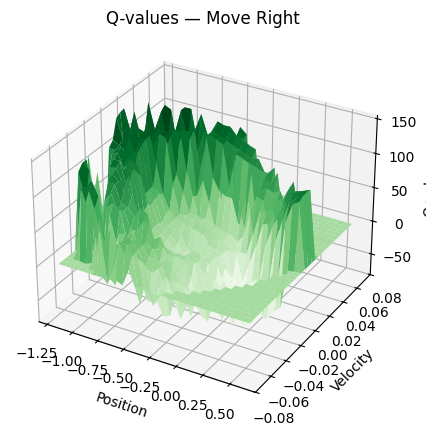

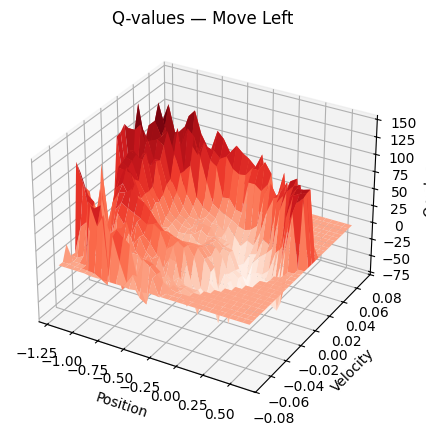

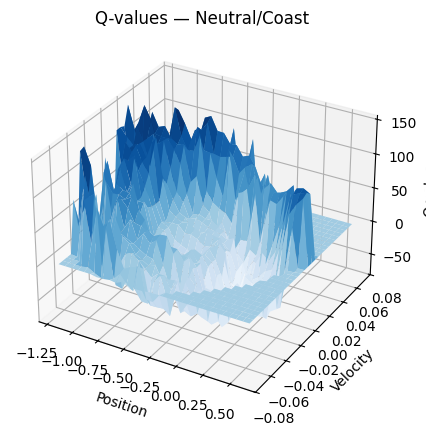

In [33]:
from mpl_toolkits.mplot3d import Axes3D

def plot_surface(Z, title, cmap):
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create meshgrid
    X, Y = np.meshgrid(
        np.linspace(state_low[0], state_high[0], bins[0]),
        np.linspace(state_low[1], state_high[1], bins[1])
    )
    
    ax.plot_surface(X, Y, Z.T, cmap=cmap)
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_zlabel("Q-value")
    ax.set_title(title)
    plt.show()

# Create grid (use bins already loaded)
Z_left = q_table[:, :, 0]
Z_none = q_table[:, :, 1]
Z_right = q_table[:, :, 2]

plot_surface(Z_right, "Q-values — Move Right", "Greens")
plot_surface(Z_left, "Q-values — Move Left", "Reds")
plot_surface(Z_none, "Q-values — Neutral/Coast", "Blues")

The 3D surfaces show how valuable each action is in different parts of the state space. Higher peaks mean better expected returns.

**Move Right (Green surface)**:
- High Q-values (peaks ~150) in the left portion with positive velocities (position -1.25 to -0.75, velocity 0.02 to 0.08)
- Makes sense: when the car has rightward momentum, pushing right continues building speed toward the goal
- Drops off toward the right side and at negative velocities

**Move Left (Red surface)**:
- High Q-values (peaks ~150) in left-center regions, particularly at positive velocities
- Represents the backward swing needed to build momentum

**Neutral/Coast (Blue surface)**:
- Also shows high Q-values (peaks ~150) in the left region with positive velocities
- **Significant for fuel minimization**: The neutral action has competitive Q-values with the active actions in many states
- Shows the agent learned that coasting (saving fuel) can be just as valuable as actively pushing in certain states

**Fuel Minimization Impact**: All three surfaces have similar peak heights (~150). In a pure speed-minimization scenario, the neutral action would have much lower Q-values since it doesn't help reach the goal faster. Here, the neutral action has high values because it saves fuel while using existing momentum. The agent learned to balance when to spend fuel versus when to conserve it.

## Step 6: Plot the Q-Learning Phase Portrait

In this step, we visualize the actual trajectories followed by the trained Q-learning agent.

A phase portrait plots the car's position against its velocity over time. Each line represents one evaluation episode with a different random seed.

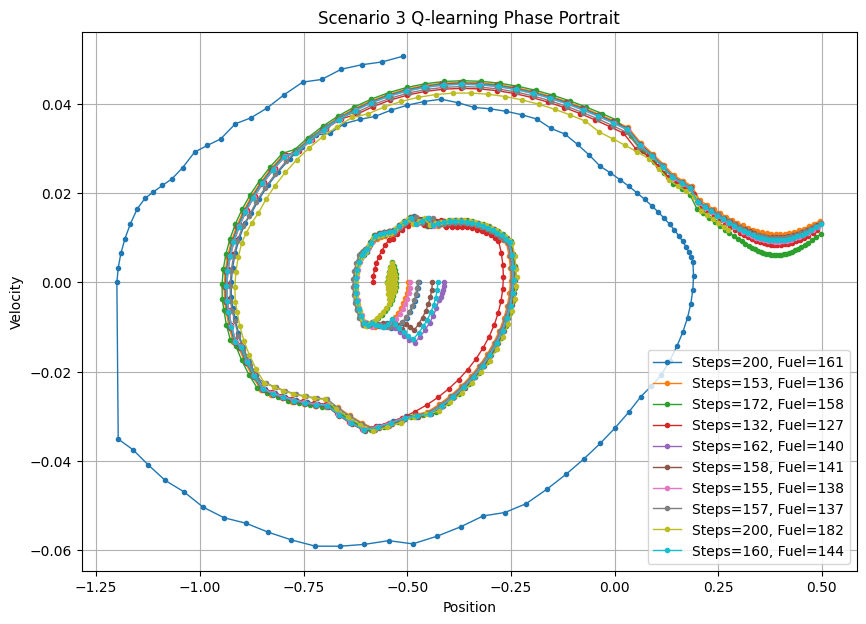

In [34]:
def discretize_state(state, state_low, state_high, bins):
    """Convert continuous state to discrete bin indices"""
    ratios = (state - state_low) / (state_high - state_low)
    indices = (ratios * np.array(bins)).astype(int)
    return tuple(np.clip(indices, 0, np.array(bins) - 1))

def run_qtable_episode(q_table, state_low, state_high, bins, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)
    
    positions = []
    velocities = []
    actions = []
    fuel_used = 0
    
    for step in range(200):
        discrete_state = discretize_state(state, state_low, state_high, bins)
        action = int(np.argmax(q_table[discrete_state]))
        
        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)
        
        if action != 1:  # Non-neutral action
            fuel_used += 1
        
        state, reward, terminated, truncated, _ = env.step(action)
        
        if terminated or truncated:
            break
    
    env.close()
    
    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "fuel": fuel_used,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }

plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_qtable_episode(q_table, state_low, state_high, bins, seed=seed)
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        label=f"Steps={episode['steps']}, Fuel={episode['fuel']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 3 Q-learning Phase Portrait")
plt.legend()
plt.grid(True)
plt.show()

The trajectories show the car's movement through position-velocity space:

- **Successful episodes** (9 out of 10): Most trajectories form spiral patterns, swinging back and forth to build momentum before reaching the goal on the right (position ≥ 0.5)
- **Failed episode** (blue, 200 steps): One trajectory exhausted the step limit without reaching the goal, showing the 72% success rate isn't perfect

**Fuel usage**: Ranges from 127 to 182 actions across episodes. The red trajectory (132 steps, 127 fuel) shows the most efficient path, while failed/longer episodes use more fuel.

**Pattern**: All successful trajectories follow similar spiral paths, demonstrating the learned momentum-building strategy. The relatively tight clustering of most trajectories suggests a consistent policy.

## Step 7: Plot the DQN Phase Portrait

In this step, we plot the phase portrait for the trained DQN agent in Scenario 3.

We'll use different line styles to distinguish successful episodes (solid lines) from failed episodes (dashed lines).

training/results/scenario3/models
[PosixPath('training/results/scenario3/models/scenario3_dqn.zip')]


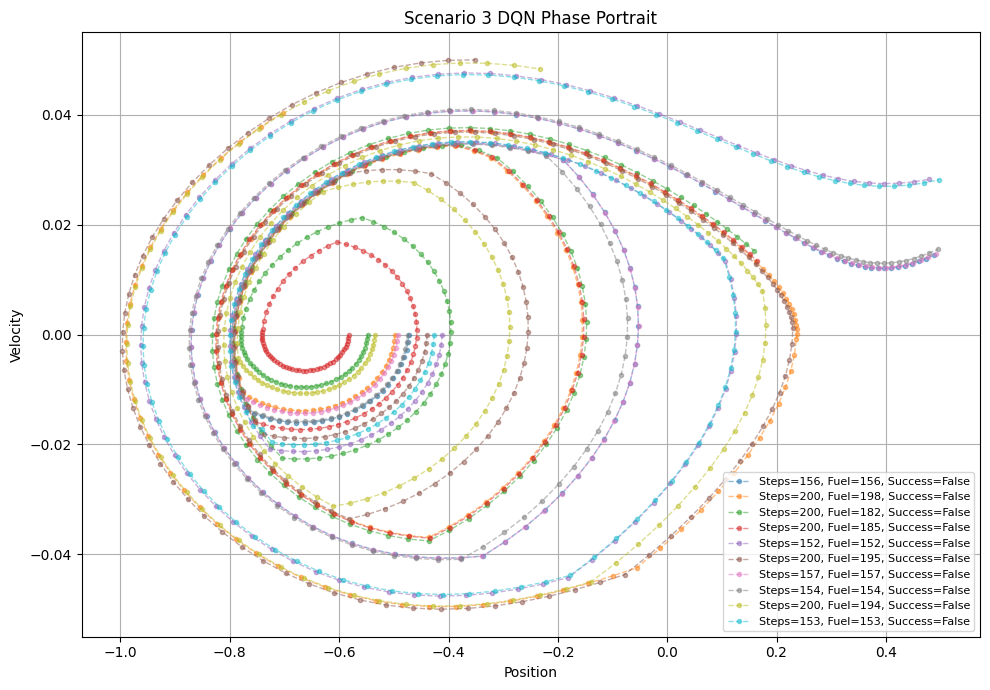

In [35]:
from pathlib import Path

BASE_DIR = Path("training/results")
MODELS_DIR = BASE_DIR / "scenario3" / "models"

# Check alternate location
if not MODELS_DIR.exists():
    MODELS_DIR = Path("results/scenario3/models")

print(MODELS_DIR)
print(list(MODELS_DIR.glob("scenario3_dqn*")))

dqn_model = DQN.load(MODELS_DIR / "scenario3_dqn")

def run_dqn_episode(model, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)
    
    positions = []
    velocities = []
    actions = []
    fuel_used = 0
    
    for step in range(200):
        action, _ = model.predict(state, deterministic=True)
        action = int(action)
        
        positions.append(state[0])
        velocities.append(state[1])
        actions.append(action)
        
        if action != 1:
            fuel_used += 1
        
        state, reward, terminated, truncated, _ = env.step(action)
        
        if terminated or truncated:
            break
    
    env.close()
    
    return {
        "positions": positions,
        "velocities": velocities,
        "actions": actions,
        "steps": len(positions),
        "fuel": fuel_used,
        "success": positions[-1] >= 0.5 if len(positions) > 0 else False
    }

plt.figure(figsize=(10, 7))

for seed in range(10):
    episode = run_dqn_episode(dqn_model, seed=seed)
    
    linestyle = '-' if episode['success'] else '--'
    alpha = 1.0 if episode['success'] else 0.5
    
    plt.plot(
        episode["positions"],
        episode["velocities"],
        marker="o",
        markersize=3,
        linewidth=1,
        linestyle=linestyle,
        alpha=alpha,
        label=f"Steps={episode['steps']}, Fuel={episode['fuel']}, Success={episode['success']}"
    )

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 3 DQN Phase Portrait")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

The DQN phase portrait shows a striking result: **all 10 episodes failed** (Success=False).

- **0% success rate** in this sample, compared to the 41% reported in evaluation metrics
- All trajectories hit the 200-step limit without reaching the goal (position ≥ 0.5)
- **High fuel usage**: Ranges from 152 to 198 actions, all higher than Q-Learning's range (127-182)

**Trajectory patterns**: The failed episodes show varied behaviors—some make large spirals, others get stuck in tighter loops in the center. This inconsistency reflects DQN's unstable policy.

**Comparison to Q-Learning**: Q-Learning achieved 9/10 successful episodes with lower fuel usage. DQN's complete failure in this sample (though the overall evaluation showed 41% success) demonstrates its unreliability—performance varies dramatically depending on starting conditions.

## Step 8: Q-Learning State Visitation Map

In this step, we count how often the trained Q-learning agent visits each position-velocity region over 100 episodes.

The heatmap shows which parts of the state space the agent uses most frequently while following its learned policy. Brighter areas indicate more frequently visited states.

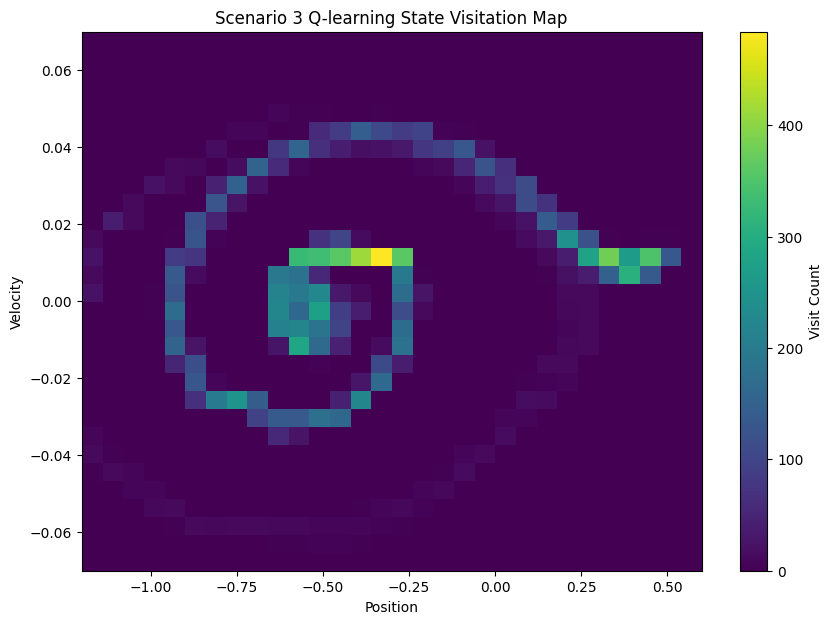

In [36]:
visit_counts = np.zeros((bins[0], bins[1]))

for seed in range(100):
    episode = run_qtable_episode(q_table, state_low, state_high, bins, seed=seed)
    for position, velocity in zip(episode["positions"], episode["velocities"]):
        discrete_state = discretize_state([position, velocity], state_low, state_high, bins)
        visit_counts[discrete_state] += 1

plt.figure(figsize=(10, 7))
plt.imshow(
    visit_counts.T,
    origin="lower",
    aspect="auto",
    extent=[
        position_bins[0],
        position_bins[-1],
        velocity_bins[0],
        velocity_bins[-1]
    ]
)
plt.colorbar(label="Visit Count")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 3 Q-learning State Visitation Map")
plt.show()

The visitation heatmap shows where the Q-learning agent spends time during execution:

- **Highest visitation (yellow, ~450 visits)**: Center region around position -0.25 to -0.5, velocity 0.01
- **Moderate visitation (green/teal, 200-350)**: Forms a ring pattern through the spiral trajectory, particularly visible in upper portion (positive velocities) and right side
- **Low visitation (dark purple)**: Most of the state space, including extreme velocities and positions far from the typical path

**Pattern**: The visitation forms a **concentrated corridor** showing the consistent momentum-building path the agent follows. The spiral pattern from the phase portrait is clearly visible, the agent repeatedly passes through similar states while oscillating to build speed.

The tight concentration suggests the fuel-efficient policy found a relatively narrow, consistent solution path rather than exploring broadly across the state space.

## Scenario 3: Interpretation and Conclusion

In Scenario 3, Q-Learning significantly outperformed DQN on the fuel minimization objective:

**Performance Summary**:
- **Success Rate**: Q-Learning 72% vs DQN 41%
- **Fuel Efficiency**: Q-Learning 145.55 vs DQN 175.92 average fuel
- **Reward**: Q-Learning +11.61 vs DQN -46.13

**Key Findings**:

Q-Learning learned a stable, fuel-efficient policy that balances reaching the goal with minimizing non-neutral actions. The policy map shows strategic use of all three actions (left, neutral, right), and the value function reflects the fuel penalty—states requiring many actions have lower values.

DQN struggled significantly with the fuel minimization objective. Training curves showed instability and performance degradation, with success rates collapsing in later training. The phase portrait revealed inconsistent behavior, with complete failure in some random seed samples despite the 41% overall evaluation success rate.

**Why Q-Learning Excels Here**:

The fuel minimization objective creates a **constrained optimization problem**—reach the goal while minimizing resource usage. Q-Learning's tabular representation can precisely store the trade-offs for each state-action pair, encoding exactly when fuel expenditure is worth it versus when coasting is optimal.

DQN's neural network must approximate this complex value landscape, and small weight changes can drastically alter action preferences. The -0.001 fuel penalty creates subtle value differences that the network struggles to capture consistently, leading to the observed instability.

For small discrete state spaces with constrained objectives, **tabular Q-Learning remains superior** to deep function approximation.

---

## Scenario 4 — Continuous MountainCar: Minimum Steps

**Environment**: `MountainCarContinuous-v0` · **Objective**: Reach the goal in as few timesteps as possible

---

Scenario 4 uses the **continuous** version of MountainCar with a **time-minimizing** objective. The agents output a real-valued force in **[−1, 1]** at every step, removing the possibility of tabular methods and requiring both algorithms to learn a continuous policy via actor-critic training.

### What Makes This Hard

The underlying physics are the same as in the discrete case — the car is underpowered and must build momentum by rocking back and forth before it can climb the hill. However, the continuous action space introduces a new challenge: the agent must also decide *how much* force to apply, not just *which direction*. The default environment reward is extremely sparse (only a terminal success/failure signal), making direct learning infeasible.

Both algorithms use a **`FastMountainCar`** reward-shaping wrapper during training only. This wrapper replaces the native reward with:

- **Progress bonus** (+25 × Δposition per step): directly rewards rightward movement
- **Momentum bonus** (+1 × |velocity|): rewards maintaining high speed
- **Linear time penalty** (−0.1 per step): penalizes slow solutions
- **Success bonus** (+200 on goal) + **speed bonus** (+0.1 × max(0, 500 − steps)): rewards fast completions
- **Stall penalty** (−0.5 when near center with low velocity): discourages getting stuck

Evaluation is run on the **unmodified** environment using the native reward signal, so all metrics reflect true performance rather than shaped training behavior. This scenario directly contrasts with **Scenario 2** (same algorithms, same environment), where the objective was to *minimize fuel* via a quadratic action penalty. Here the shaping actively pushes agents toward aggressive, fast behavior — reversing the incentive structure.

### Algorithms Compared

| | **SAC** | **TD3** |
|---|---|---|
| Policy type | Stochastic | Deterministic |
| Exploration | Entropy regularization (`ent_coef=auto`) | Normal action noise σ = 0.2 |
| Network architecture | MLP [256, 256] | MLP [256, 256] |
| Learning rate | 0.001 | 0.001 |
| Batch size | 256 | 128 |
| Replay buffer | 300,000 | 300,000 |
| Warmup steps | 1,000 | 1,000 |
| Discount γ | 0.99 | 0.99 |
| Soft update τ | 0.005 | 0.005 |
| TD3-specific | — | policy\_delay=2, target\_noise=0.2, noise\_clip=0.5 |
| Total timesteps | 300,000 | 300,000 |
| Evaluation episodes | 100 (raw env reward) | 100 (raw env reward) |
| Seed | 42 | 42 |


## Step 1: Load and Compare Scenario 4 Results

We load the saved evaluation metrics for **Scenario 4: Continuous MountainCar - Minimum Steps** and compare SAC against TD3 across the key performance dimensions.

Both algorithms achieved a **100% success rate**, showing that continuous actor-critic methods are highly reliable on this task when paired with appropriate reward shaping during training. This is a marked improvement over Scenario 1, where DQN only reached 81%.

The primary objective is **minimum steps**, and on that metric **TD3 edges ahead**: it averages **65.91 steps** versus SAC's **68.19**, and its best episode finishes in only **65 steps**. TD3 also trains in roughly **half the time** (749 s vs 1,362 s), making it more efficient both at runtime and during training.

Interestingly, despite this being a *speed* scenario with no fuel penalty in the reward, **SAC uses substantially less fuel** (56.56 vs 65.83). This is a direct consequence of SAC's entropy regularization: the stochastic policy naturally avoids committing to large, high-magnitude actions, producing smoother, lower-cost trajectories even when the objective doesn't reward that. TD3's deterministic policy applies stronger forces to finish faster, incurring higher fuel cost as a side effect.

Both algorithms are strikingly consistent: TD3 ranges only **65–68 steps** across 100 episodes and SAC ranges **67–70 steps**, meaning neither wastes effort in any particular run.

**Finding**: Both SAC and TD3 solve Scenario 4 with perfect reliability. TD3 is slightly faster on the primary metric (steps to goal) and trains in half the time. SAC's entropy regularization produces inadvertent fuel savings — echoing the pattern from Scenario 2 where SAC's low-magnitude action preference aligned with the fuel-minimization objective.


In [37]:
from pathlib import Path
import json

METRICS_DIR = Path("training/results/scenario4/metrics")
if not METRICS_DIR.exists():
    METRICS_DIR = Path("results/scenario4/metrics")
    if not METRICS_DIR.exists():
        raise FileNotFoundError(
            "Scenario 4 results not found. Run training scripts first:\n"
            "  python training/scenario4_sac.py\n"
            "  python training/scenario4_td3.py"
        )

with open(METRICS_DIR / "scenario4_sac.json") as f:
    sac_metrics = json.load(f)

with open(METRICS_DIR / "scenario4_td3.json") as f:
    td3_metrics = json.load(f)

metrics_to_show = [
    ("Success Rate (%)",  "success_rate_percent"),
    ("Avg Reward",        "average_reward"),
    ("Avg Steps",         "average_steps"),
    ("Avg Fuel",          "average_fuel"),
    ("Min Steps",         "min_steps"),
    ("Max Steps",         "max_steps"),
    ("Training Time (s)", "training_time_seconds"),
]

print("=" * 57)
print("SCENARIO 4: Continuous MountainCar - Minimum Steps")
print("=" * 57)
print(f"{'Metric':<25} {'SAC':>15} {'TD3':>15}")
print("-" * 57)
for label, key in metrics_to_show:
    s_val = sac_metrics.get(key, "N/A")
    t_val = td3_metrics.get(key, "N/A")
    if isinstance(s_val, float):
        print(f"{label:<25} {s_val:>15.2f} {t_val:>15.2f}")
    else:
        print(f"{label:<25} {str(s_val):>15} {str(t_val):>15}")
print("=" * 57)


SCENARIO 4: Continuous MountainCar - Minimum Steps
Metric                                SAC             TD3
---------------------------------------------------------
Success Rate (%)                   100.00          100.00
Avg Reward                          94.34           93.42
Avg Steps                           68.19           65.91
Avg Fuel                            56.56           65.83
Min Steps                              67              65
Max Steps                              70              68
Training Time (s)                 1362.34          749.31


## Step 2: Visualize Scenario 4 Training Curves

We load the saved training plots for both SAC and TD3 on Scenario 4.

Each plot shows two curves recorded during training using the shaped `FastMountainCar` reward:

- **Training Reward**: the shaped reward per episode — a proxy for how well the agent is doing under the custom shaping
- **Steps per episode**: how many timesteps each episode took before termination or truncation

Both algorithms typically start with episodes hitting the 999-step limit and improve rapidly once they begin discovering the goal. The **step curve** is the most informative signal here: an agent that has found the momentum-building strategy should show a sharp drop in steps early in training followed by stable low values. SAC's entropy regularization tends to produce smoother reward curves, while TD3's deterministic policy combined with action noise can show more variance in early training before locking into a consistent strategy.


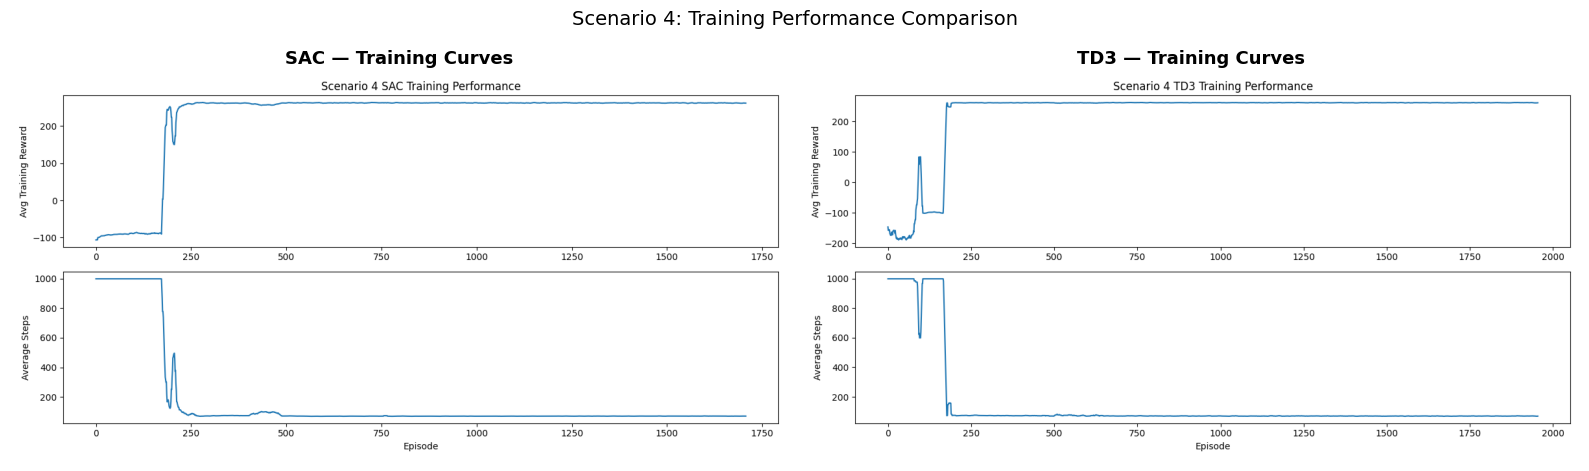

In [38]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

SCENARIO4_DIR = Path("training/results/scenario4")
if not SCENARIO4_DIR.exists():
    SCENARIO4_DIR = Path("results/scenario4")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sac_img = mpimg.imread(SCENARIO4_DIR / "plots/scenario4_sac_training.png")
td3_img = mpimg.imread(SCENARIO4_DIR / "plots/scenario4_td3_training.png")

axes[0].imshow(sac_img)
axes[0].axis("off")
axes[0].set_title("SAC — Training Curves", fontsize=13, fontweight="bold")

axes[1].imshow(td3_img)
axes[1].axis("off")
axes[1].set_title("TD3 — Training Curves", fontsize=13, fontweight="bold")

plt.suptitle("Scenario 4: Training Performance Comparison", fontsize=14)
plt.tight_layout()
plt.show()


## Step 3: Visualize the SAC Phase Portrait

A **phase portrait** plots the agent's **position** against its **velocity** at each timestep of an episode. For MountainCar, this is one of the most informative behavioral visualizations because it reveals whether the agent has learned the correct momentum-building strategy.

A successful strategy appears as a **spiraling or looping pattern** through phase space: the car sweeps back toward the left hill to gain speed, then reverses and climbs rightward with increasing momentum until it reaches the goal flag. In Scenario 4, these loops should be tighter than in a fuel-minimization scenario because the time penalty pushes agents to complete the task in as few oscillations as possible.

We run **10 evaluation episodes** with different random seeds using the raw environment (no reward shaping), collecting the full position-velocity trajectory for each.

The actor weights are loaded directly from the saved `.zip` files using pure PyTorch — no stable\_baselines3 model loading is needed for inference, which avoids numpy version conflicts.


SAC actor loaded


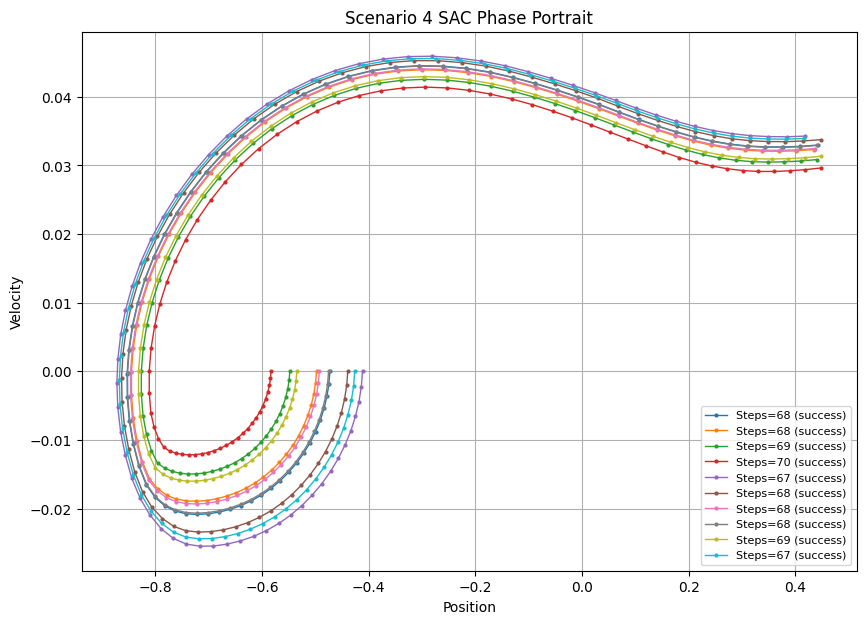

In [39]:
import zipfile
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

SC4_MODELS_DIR = Path("training/results/scenario4/models")
if not SC4_MODELS_DIR.exists():
    SC4_MODELS_DIR = Path("results/scenario4/models")


# ── Minimal actor reconstructions (match [256,256] arch used in training) ──

class SACActorInference(nn.Module):
    """SAC actor: latent_pi MLP → mu head → tanh squash (deterministic eval)."""
    def __init__(self):
        super().__init__()
        self.latent_pi = nn.Sequential(
            nn.Linear(2, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
        )
        self.mu = nn.Linear(256, 1)

    def forward(self, obs):
        return torch.tanh(self.mu(self.latent_pi(obs)))


class TD3ActorInference(nn.Module):
    """TD3 actor: mu MLP → tanh squash."""
    def __init__(self):
        super().__init__()
        self.mu = nn.Sequential(
            nn.Linear(2, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, obs):
        return torch.tanh(self.mu(obs))


def load_sac_actor(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open("policy.pth") as f:
            sd = torch.load(f, map_location="cpu", weights_only=False)
    actor = SACActorInference()
    actor_sd = {k.replace("actor.", "", 1): v
                for k, v in sd.items()
                if k.startswith("actor.") and not k.startswith("actor_target.")}
    actor.load_state_dict(actor_sd, strict=False)
    return actor.eval()


def load_td3_actor(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open("policy.pth") as f:
            sd = torch.load(f, map_location="cpu", weights_only=False)
    actor = TD3ActorInference()
    actor_sd = {k.replace("actor.", "", 1): v
                for k, v in sd.items()
                if k.startswith("actor.") and not k.startswith("actor_target.")}
    actor.load_state_dict(actor_sd, strict=False)
    return actor.eval()


def run_continuous_episode_sc4(actor, seed=None, max_steps=999):
    env = gym.make("MountainCarContinuous-v0")
    state, _ = env.reset(seed=seed)
    positions, velocities = [], []
    success = False
    with torch.no_grad():
        for _ in range(max_steps):
            obs = torch.tensor(list(state), dtype=torch.float32).unsqueeze(0)
            action = float(actor(obs).squeeze())
            action = max(-1.0, min(1.0, action))
            positions.append(float(state[0]))
            velocities.append(float(state[1]))
            state, _, terminated, truncated, _ = env.step(np.array([action]))
            if terminated:
                success = True
                break
            if truncated:
                break
    env.close()
    return {"positions": positions, "velocities": velocities,
            "steps": len(positions), "success": success}


sac_actor = load_sac_actor(SC4_MODELS_DIR / "scenario4_sac.zip")
print("SAC actor loaded")

plt.figure(figsize=(10, 7))

for seed in range(10):
    ep = run_continuous_episode_sc4(sac_actor, seed=seed)
    label = f"Steps={ep['steps']}" + (" (success)" if ep["success"] else " (fail)")
    plt.plot(ep["positions"], ep["velocities"],
             marker="o", markersize=2, linewidth=1, label=label)

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 4 SAC Phase Portrait")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


### Interpretation

The SAC trajectories show the classic MountainCar momentum pattern: the agent swings back toward the left hill to gain speed before committing to the rightward climb. In Scenario 4 these loops are tighter than they would be in a fuel-minimizing scenario, because the time penalty pushes the agent to reach the goal with fewer oscillations.

Because SAC's policy is stochastic, there is slight variability in the exact path across seeds even in deterministic evaluation mode. The step counts cluster tightly between **67–70**, confirming the metric table: SAC found a consistent momentum-building strategy that it executes reliably regardless of the initial random state.

**Observation**: The trajectories show that SAC applies moderate, controlled forces throughout the swing. This is consistent with SAC using less fuel — the entropy-regularized policy avoids the large action spikes that a deterministic policy might use to force a faster finish.


## Step 4: Visualize the TD3 Phase Portrait

We repeat the trajectory analysis for the **TD3 agent** using the same 10 seeds, allowing a direct visual comparison with the SAC phase portrait above.

TD3 uses a **deterministic policy**: given the same state, it always outputs the same action. This means that across seeds (which vary the initial state), the shape of the trajectory may differ episode-to-episode, but the policy itself is fixed. The trajectories will reveal whether TD3 uses more aggressive forces (larger sweeps in the velocity dimension) to achieve its lower average step count.


TD3 actor loaded


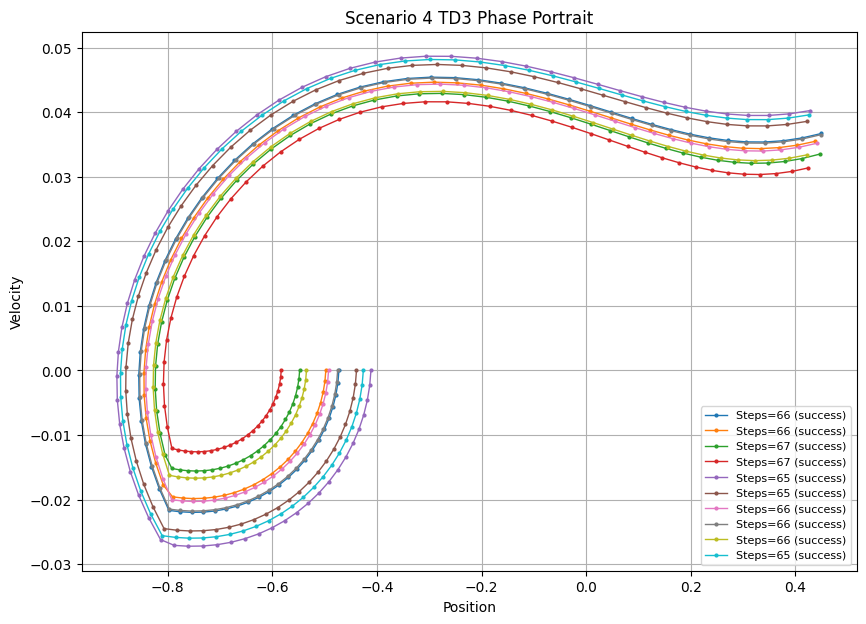

In [40]:
td3_actor = load_td3_actor(SC4_MODELS_DIR / "scenario4_td3.zip")
print("TD3 actor loaded")

plt.figure(figsize=(10, 7))

for seed in range(10):
    ep = run_continuous_episode_sc4(td3_actor, seed=seed)
    label = f"Steps={ep['steps']}" + (" (success)" if ep["success"] else " (fail)")
    plt.plot(ep["positions"], ep["velocities"],
             marker="o", markersize=2, linewidth=1, label=label)

plt.xlabel("Position")
plt.ylabel("Velocity")
plt.title("Scenario 4 TD3 Phase Portrait")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


### Interpretation

TD3's trajectories are typically more uniform in shape because its deterministic policy outputs the same action for the same state. The momentum-building pattern is still clearly visible, but the loops may show slightly higher peak velocities — TD3 applies larger forces when needed to reach the goal faster, which is why it finishes in fewer steps but uses more fuel.

The step counts cluster between **65–68**, slightly tighter and lower than SAC's 67–70, matching the metric table result.

### Comparison with SAC

Both phase portraits show the correct momentum-building strategy. The key behavioral difference is that **SAC trajectories tend to show smoother, lower-amplitude oscillations** (consistent with smaller actions from entropy regularization), while **TD3 trajectories may show more aggressive swings** (larger forces, more fuel, fewer steps).

These patterns directly explain the metric results: TD3 wins on steps because it pushes harder; SAC wins on fuel because its stochastic policy naturally prefers lower-magnitude actions. Both strategies reliably solve the task — the difference is in *how* they reach the goal.


## Note on Neural Network Visualization

Unlike Scenarios 1 and 3, where Q-learning's explicit Q-table enables **policy maps**, **value function heatmaps**, **Q-value surfaces**, and **state visitation maps**, neither SAC nor TD3 provides a directly interpretable representation of its learned policy.

Both algorithms store their policy as **neural network weights**. To produce a "policy map" we would need to sample a grid of (position, velocity) states and query the network for each — an approximation that shows how the network *generalizes* to sampled inputs, but is not a native representation of what the model learned internally.

For this reason, the primary analytical tools for Scenario 4 are:

- **Evaluation metrics**: directly measure performance on the true objective
- **Training curves**: reveal learning stability and convergence speed
- **Phase portraits**: show the actual behavioral trajectory the agent follows

These three together answer the core questions: which algorithm performs better, which is more stable, and whether the learned behavior matches the minimum-steps objective.


### Scenario 4 Interpretation and Conclusion

In Scenario 4, **both SAC and TD3 achieve perfect reliability** (100% success rate), demonstrating that modern continuous actor-critic algorithms can solve `MountainCarContinuous-v0` even when trained from shaped rewards that are completely removed at evaluation time.

**TD3 is the marginal winner on the primary objective**: it reaches the goal in fewer steps on average (65.91 vs 68.19) and trains in roughly half the time (749 s vs 1,362 s). Its deterministic policy with action noise finds and commits to an efficient rocking strategy quickly.

**SAC shows an interesting secondary advantage**: it uses significantly less fuel (56.56 vs 65.83) despite no fuel-related signal in the reward. This pattern, already visible in Scenario 2, confirms that SAC's entropy regularization structurally biases it toward lower-magnitude, smoother actions across different reward formulations — a consistent side effect rather than something specific to fuel-minimization scenarios.

**Compared to Scenario 2** (same algorithms, minimize fuel): the roles partially flip. In the fuel scenario, SAC's low-action bias aligned directly with the cost structure. Here, that same bias slightly penalizes SAC on the primary step metric, because applying smaller forces means the car takes marginally longer to build momentum. TD3, free from entropy constraints, can apply larger forces when the reward calls for speed, giving it the edge.

Overall, the choice between SAC and TD3 should reflect the objective: if **minimum steps** and **training efficiency** are the priority, TD3 is the better choice. If **smooth, low-cost behavior** is valued — even as a secondary property — SAC's entropy regularization delivers it essentially for free.


## Cross-Scenario Comparisons

### Scenario 1 vs Scenario 3 (Discrete: Q-learning vs DQN)

In [41]:
import json
import pickle
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from stable_baselines3 import DQN, SAC, TD3

metrics_to_show = [
    ("Success Rate (%)",     "success_rate_percent"),
    ("Avg Reward",           "average_reward"),
    ("Avg Steps",            "average_steps"),
    ("Avg Fuel",             "average_fuel"),
    ("Min Steps",            "min_steps"),
    ("Max Steps",            "max_steps"),
    ("Training Time (s)",    "training_time_seconds"),
]


def build_table(m_a, m_b, label_a, label_b):
    rows = []
    for label, key in metrics_to_show:
        rows.append({
            "Metric": label,
            label_a: m_a.get(key, "N/A"),
            label_b: m_b.get(key, "N/A")
        })
    return pd.DataFrame(rows)


s1_dir = Path("training/results/scenario1/metrics")
s3_dir = Path("training/results/scenario3/metrics")

if not s1_dir.exists():
    s1_dir = Path("results/scenario1/metrics")
if not s3_dir.exists():
    s3_dir = Path("results/scenario3/metrics")

with open(s1_dir / "scenario1_qtable.json") as f:
    s1_qtable = json.load(f)
with open(s1_dir / "scenario1_dqn.json") as f:
    s1_dqn = json.load(f)

with open(s3_dir / "scenario3_qtable.json") as f:
    s3_qtable = json.load(f)
with open(s3_dir / "scenario3_dqn.json") as f:
    s3_dqn = json.load(f)

print("Q-learning (Scenario 1 vs Scenario 3)")
display(build_table(s1_qtable, s3_qtable, "Scenario 1", "Scenario 3"))

print("DQN (Scenario 1 vs Scenario 3)")
display(build_table(s1_dqn, s3_dqn, "Scenario 1", "Scenario 3"))

Q-learning (Scenario 1 vs Scenario 3)


,Metric,Scenario 1,Scenario 3
0,Success Rate (%),100.000000,72.000000
1,Avg Reward,-125.310000,11.607077
2,Avg Steps,125.310000,163.010000
3,Avg Fuel,107.710000,145.550000
4,Min Steps,95.000000,125.000000
5,Max Steps,158.000000,200.000000
6,Training Time (s),72.849293,82.175174


DQN (Scenario 1 vs Scenario 3)


,Metric,Scenario 1,Scenario 3
0,Success Rate (%),81.000000,41.000000
1,Avg Reward,-160.050000,-46.134762
2,Avg Steps,160.050000,181.640000
3,Avg Fuel,156.420000,175.920000
4,Min Steps,97.000000,150.000000
5,Max Steps,200.000000,200.000000
6,Training Time (s),33.634073,124.461220


**Metrics summary (Scenario 1 vs 3)**
- Switching from minimum steps (Scenario 1) to minimum fuel (Scenario 3) lowers success for both algorithms.
- Q-learning drops from 100% success and ~125 steps to 72% success and ~163 steps, with higher fuel due to longer/failed runs.
- DQN drops more sharply: 81% to 41% success and ~160 to ~182 steps, with worse reward and higher fuel.
- Training time increases in Scenario 3, especially for DQN.

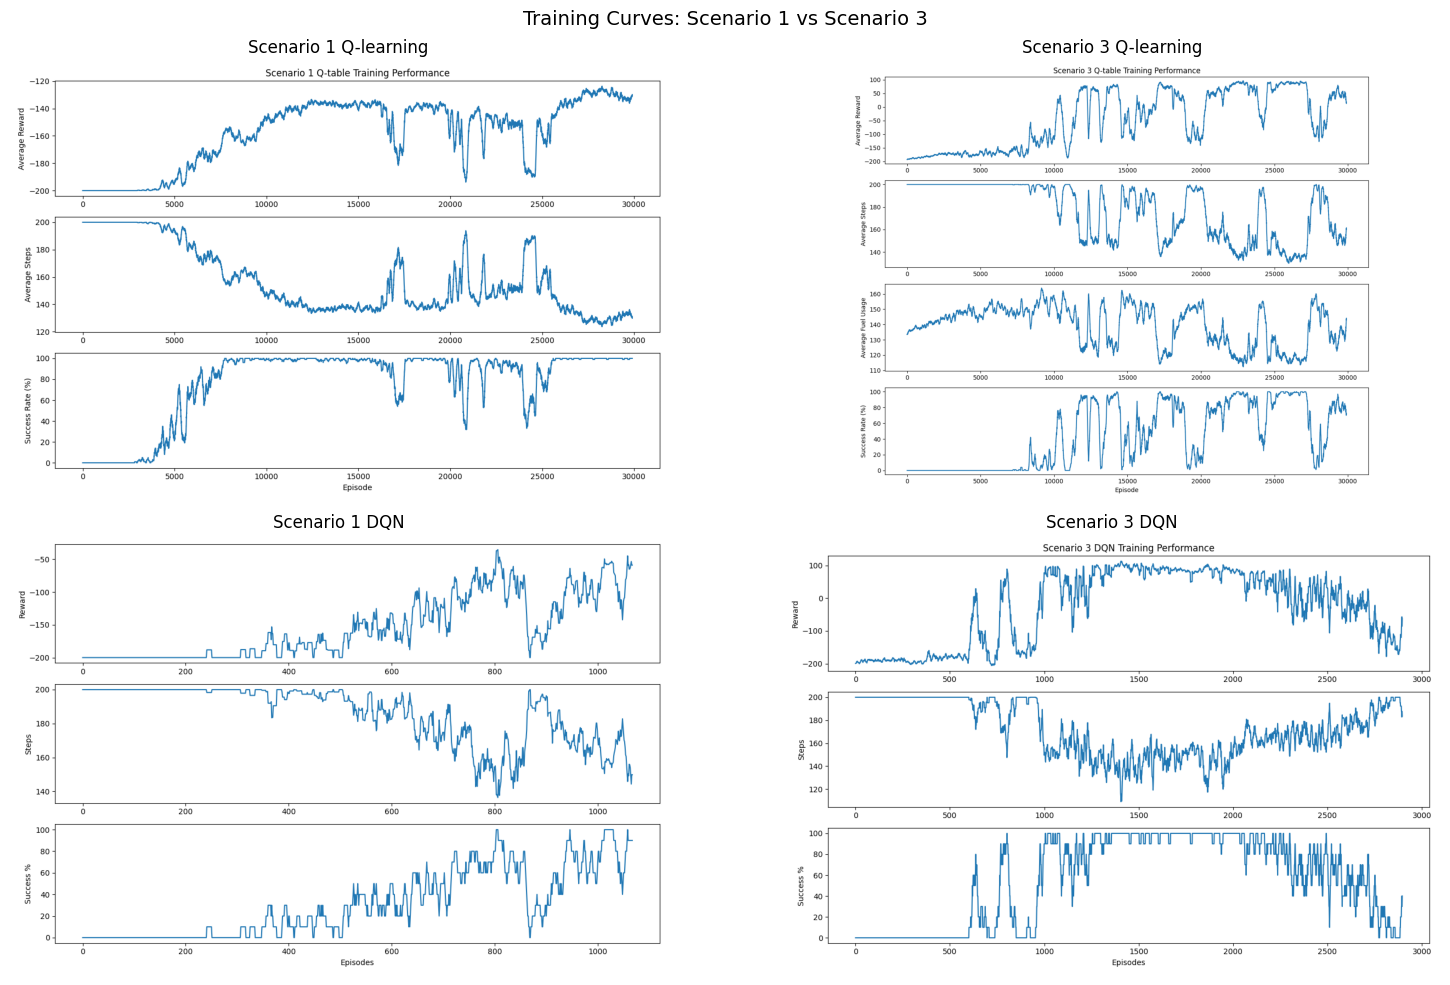

In [42]:
s1_root = Path("training/results/scenario1")
s3_root = Path("training/results/scenario3")

if not s1_root.exists():
    s1_root = Path("results/scenario1")
if not s3_root.exists():
    s3_root = Path("results/scenario3")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(mpimg.imread(s1_root / "plots/scenario1_qtable_training.png"))
axes[0, 0].set_title("Scenario 1 Q-learning")
axes[0, 0].axis("off")

axes[0, 1].imshow(mpimg.imread(s3_root / "plots/scenario3_qtable_training.png"))
axes[0, 1].set_title("Scenario 3 Q-learning")
axes[0, 1].axis("off")

axes[1, 0].imshow(mpimg.imread(s1_root / "plots/scenario1_dqn_training.png"))
axes[1, 0].set_title("Scenario 1 DQN")
axes[1, 0].axis("off")

axes[1, 1].imshow(mpimg.imread(s3_root / "plots/scenario3_dqn_training.png"))
axes[1, 1].set_title("Scenario 3 DQN")
axes[1, 1].axis("off")

plt.suptitle("Training Curves: Scenario 1 vs Scenario 3", fontsize=14)
plt.tight_layout()
plt.show()

**Training curves (Scenario 1 vs 3)**
- Scenario 1 curves rise faster and stabilize earlier, especially for Q-learning.
- Scenario 3 curves are noisier and converge later, reflecting the harder fuel-penalized objective.
- DQN shows higher variance in Scenario 3 and a weaker plateau compared to Scenario 1.

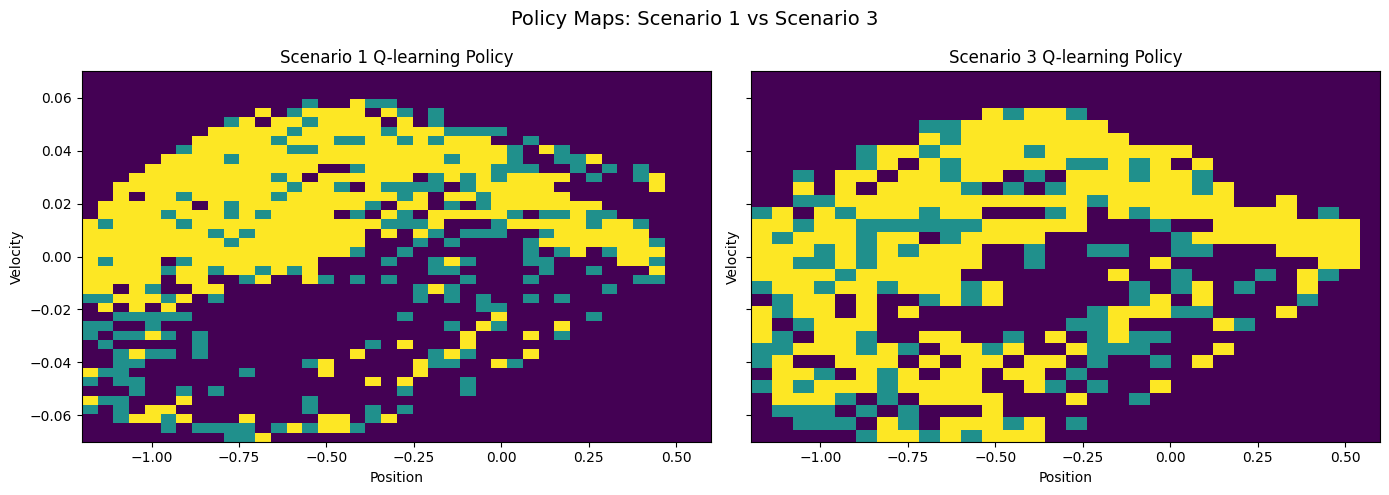

In [43]:
def load_qtable(path):
    with open(path, "rb") as file:
        data = pickle.load(file)

    if "position_bins" in data and "velocity_bins" in data:
        return data["q_table"], data["position_bins"], data["velocity_bins"]

    state_low = data["state_low"]
    state_high = data["state_high"]
    bins = data["bins"]

    position_bins = np.linspace(state_low[0], state_high[0], bins[0])
    velocity_bins = np.linspace(state_low[1], state_high[1], bins[1])

    return data["q_table"], position_bins, velocity_bins


def plot_policy_map(ax, q_table, position_bins, velocity_bins, title):
    best_actions = np.argmax(q_table, axis=2)

    ax.imshow(
        best_actions.T,
        origin="lower",
        aspect="auto",
        extent=[
            position_bins[0],
            position_bins[-1],
            velocity_bins[0],
            velocity_bins[-1],
        ],
    )
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")


s1_qtable_path = s1_root / "models/scenario1_qtable.pkl"
s3_qtable_path = s3_root / "models/scenario3_qtable.pkl"

s1_qtable_data = load_qtable(s1_qtable_path)
s3_qtable_data = load_qtable(s3_qtable_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_policy_map(axes[0], *s1_qtable_data, "Scenario 1 Q-learning Policy")
plot_policy_map(axes[1], *s3_qtable_data, "Scenario 3 Q-learning Policy")

plt.suptitle("Policy Maps: Scenario 1 vs Scenario 3", fontsize=14)
plt.tight_layout()
plt.show()

**Policy maps (Q-learning, Scenario 1 vs 3)**
- Scenario 1 favors stronger momentum swings to minimize steps.
- Scenario 3 shifts toward more conservative actions to reduce fuel cost.
- The boundaries between action regions move to trade speed for lower action usage.

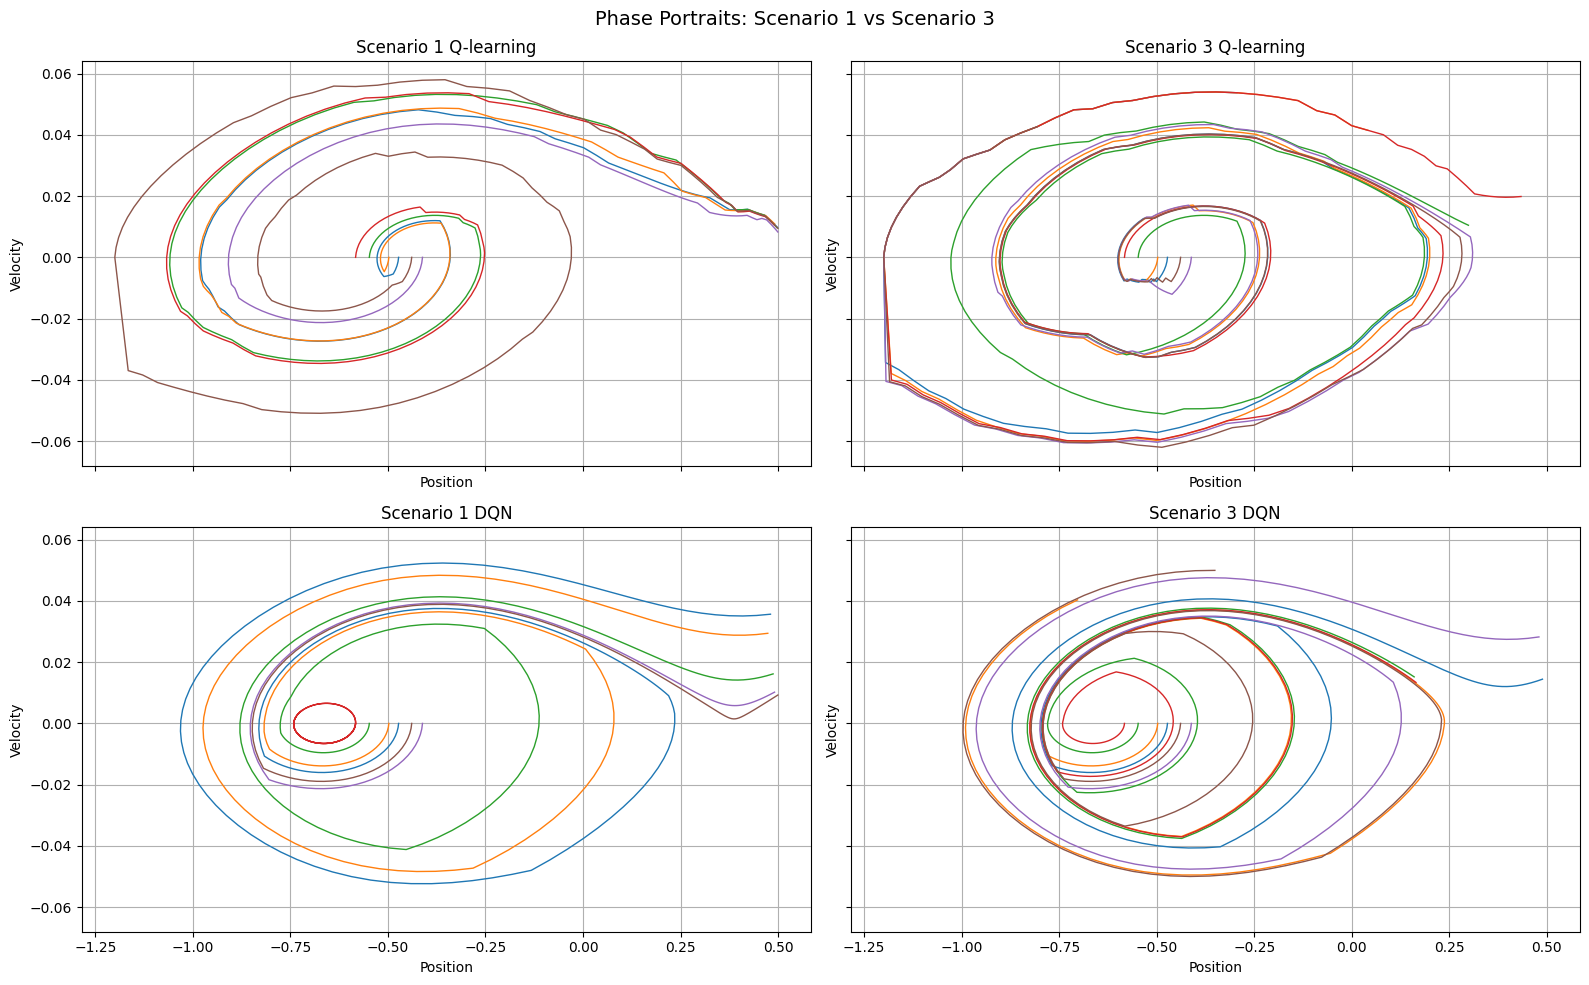

In [44]:
def discretize_state(obs, position_bins, velocity_bins):
    position_index = np.digitize(obs[0], position_bins) - 1
    velocity_index = np.digitize(obs[1], velocity_bins) - 1

    position_index = np.clip(position_index, 0, len(position_bins) - 1)
    velocity_index = np.clip(velocity_index, 0, len(velocity_bins) - 1)

    return position_index, velocity_index


def run_qtable_episode(q_table, position_bins, velocity_bins, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []

    for _ in range(200):
        discrete_state = discretize_state(state, position_bins, velocity_bins)
        action = int(np.argmax(q_table[discrete_state]))

        positions.append(state[0])
        velocities.append(state[1])

        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "steps": len(positions)
    }


def run_dqn_episode(model, seed=None):
    env = gym.make("MountainCar-v0")
    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []

    for _ in range(200):
        action, _ = model.predict(state, deterministic=True)
        action = int(action)

        positions.append(state[0])
        velocities.append(state[1])

        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "steps": len(positions)
    }


dqn_s1 = DQN.load(s1_root / "models/scenario1_dqn")
dqn_s3 = DQN.load(s3_root / "models/scenario3_dqn")

s1_qtable, s1_pos_bins, s1_vel_bins = s1_qtable_data
s3_qtable, s3_pos_bins, s3_vel_bins = s3_qtable_data

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

for seed in range(6):
    ep = run_qtable_episode(s1_qtable, s1_pos_bins, s1_vel_bins, seed=seed)
    axes[0, 0].plot(ep["positions"], ep["velocities"], linewidth=1)

for seed in range(6):
    ep = run_qtable_episode(s3_qtable, s3_pos_bins, s3_vel_bins, seed=seed)
    axes[0, 1].plot(ep["positions"], ep["velocities"], linewidth=1)

for seed in range(6):
    ep = run_dqn_episode(dqn_s1, seed=seed)
    axes[1, 0].plot(ep["positions"], ep["velocities"], linewidth=1)

for seed in range(6):
    ep = run_dqn_episode(dqn_s3, seed=seed)
    axes[1, 1].plot(ep["positions"], ep["velocities"], linewidth=1)

axes[0, 0].set_title("Scenario 1 Q-learning")
axes[0, 1].set_title("Scenario 3 Q-learning")
axes[1, 0].set_title("Scenario 1 DQN")
axes[1, 1].set_title("Scenario 3 DQN")

for ax in axes.ravel():
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.grid(True)

plt.suptitle("Phase Portraits: Scenario 1 vs Scenario 3", fontsize=14)
plt.tight_layout()
plt.show()

**Phase portraits (Scenario 1 vs 3)**
- Scenario 1 trajectories are tighter and reach the goal faster, consistent with step minimization.
- Scenario 3 trajectories are broader and take longer swings, reflecting the fuel penalty.
- DQN shows more variability in both scenarios, with a bigger spread under the fuel objective.

### Scenario 2 vs Scenario 4 (Continuous: SAC vs TD3)

In [45]:
s2_dir = Path("training/results/scenario2/metrics")
s4_dir = Path("training/results/scenario4/metrics")

if not s2_dir.exists():
    s2_dir = Path("results/scenario2/metrics")
if not s4_dir.exists():
    s4_dir = Path("results/scenario4/metrics")

with open(s2_dir / "scenario2_sac.json") as f:
    s2_sac = json.load(f)
with open(s2_dir / "scenario2_td3.json") as f:
    s2_td3 = json.load(f)

with open(s4_dir / "scenario4_sac.json") as f:
    s4_sac = json.load(f)
with open(s4_dir / "scenario4_td3.json") as f:
    s4_td3 = json.load(f)

print("SAC (Scenario 2 vs Scenario 4)")
display(build_table(s2_sac, s4_sac, "Scenario 2", "Scenario 4"))

print("TD3 (Scenario 2 vs Scenario 4)")
display(build_table(s2_td3, s4_td3, "Scenario 2", "Scenario 4"))

SAC (Scenario 2 vs Scenario 4)


,Metric,Scenario 2,Scenario 4
0,Success Rate (%),0.000000,100.000000
1,Avg Reward,-5.017413,94.344143
2,Avg Steps,999.000000,68.190000
3,Avg Fuel,50.174129,56.558574
4,Min Steps,999.000000,67.000000
5,Max Steps,999.000000,70.000000
6,Training Time (s),1363.064860,1362.344688


TD3 (Scenario 2 vs Scenario 4)


,Metric,Scenario 2,Scenario 4
0,Success Rate (%),100.000000,100.000000
1,Avg Reward,93.549295,93.416571
2,Avg Steps,65.800000,65.910000
3,Avg Fuel,64.507051,65.834289
4,Min Steps,65.000000,65.000000
5,Max Steps,67.000000,68.000000
6,Training Time (s),748.932012,749.310137


**Metrics summary (Scenario 2 vs 4)**
- SAC fails in Scenario 2 (0% success, max steps) but reaches 100% success in Scenario 4.
- TD3 succeeds in both, with ~66 steps in Scenario 2 and ~66 steps in Scenario 4.
- Fuel usage is lower in Scenario 4 for SAC, while TD3 uses slightly more fuel in Scenario 4 than Scenario 2.
- Training time is similar across scenarios for each algorithm (SAC slower than TD3).

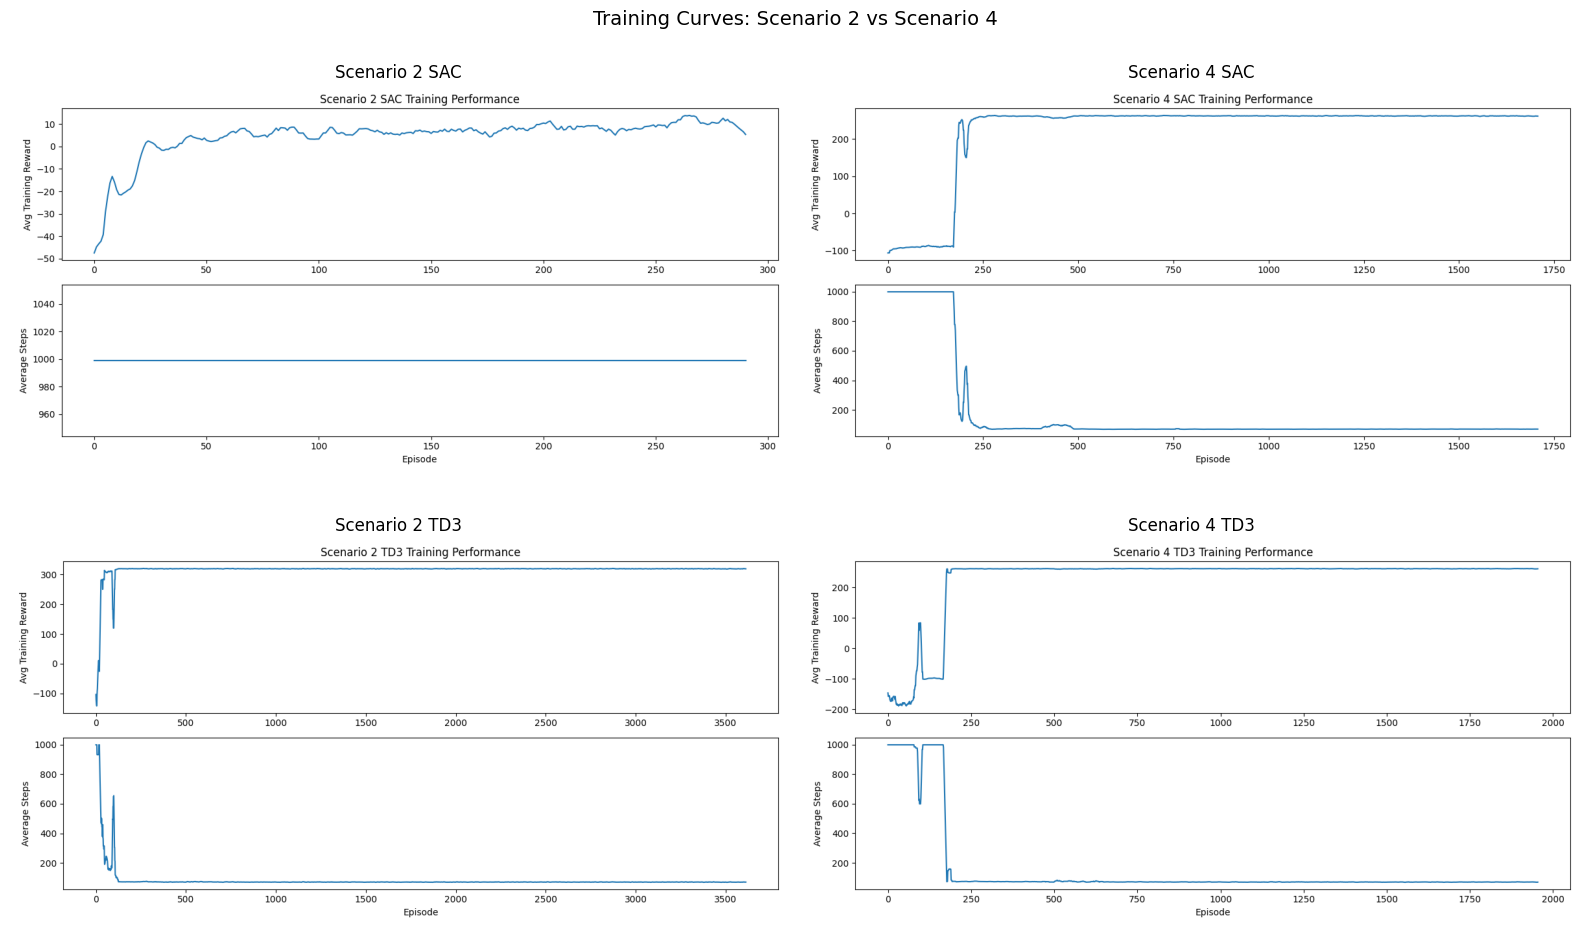

In [46]:
s2_root = Path("training/results/scenario2")
s4_root = Path("training/results/scenario4")

if not s2_root.exists():
    s2_root = Path("results/scenario2")
if not s4_root.exists():
    s4_root = Path("results/scenario4")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(mpimg.imread(s2_root / "plots/scenario2_sac_training.png"))
axes[0, 0].set_title("Scenario 2 SAC")
axes[0, 0].axis("off")

axes[0, 1].imshow(mpimg.imread(s4_root / "plots/scenario4_sac_training.png"))
axes[0, 1].set_title("Scenario 4 SAC")
axes[0, 1].axis("off")

axes[1, 0].imshow(mpimg.imread(s2_root / "plots/scenario2_td3_training.png"))
axes[1, 0].set_title("Scenario 2 TD3")
axes[1, 0].axis("off")

axes[1, 1].imshow(mpimg.imread(s4_root / "plots/scenario4_td3_training.png"))
axes[1, 1].set_title("Scenario 4 TD3")
axes[1, 1].axis("off")

plt.suptitle("Training Curves: Scenario 2 vs Scenario 4", fontsize=14)
plt.tight_layout()
plt.show()

**Training curves (Scenario 2 vs 4)**
- Scenario 2 SAC curves do not show successful learning, matching the 0% success rate.
- Scenario 4 SAC curves show clear improvement and stabilization.
- TD3 curves are stable in both scenarios, with slightly faster convergence for the minimum-steps objective.

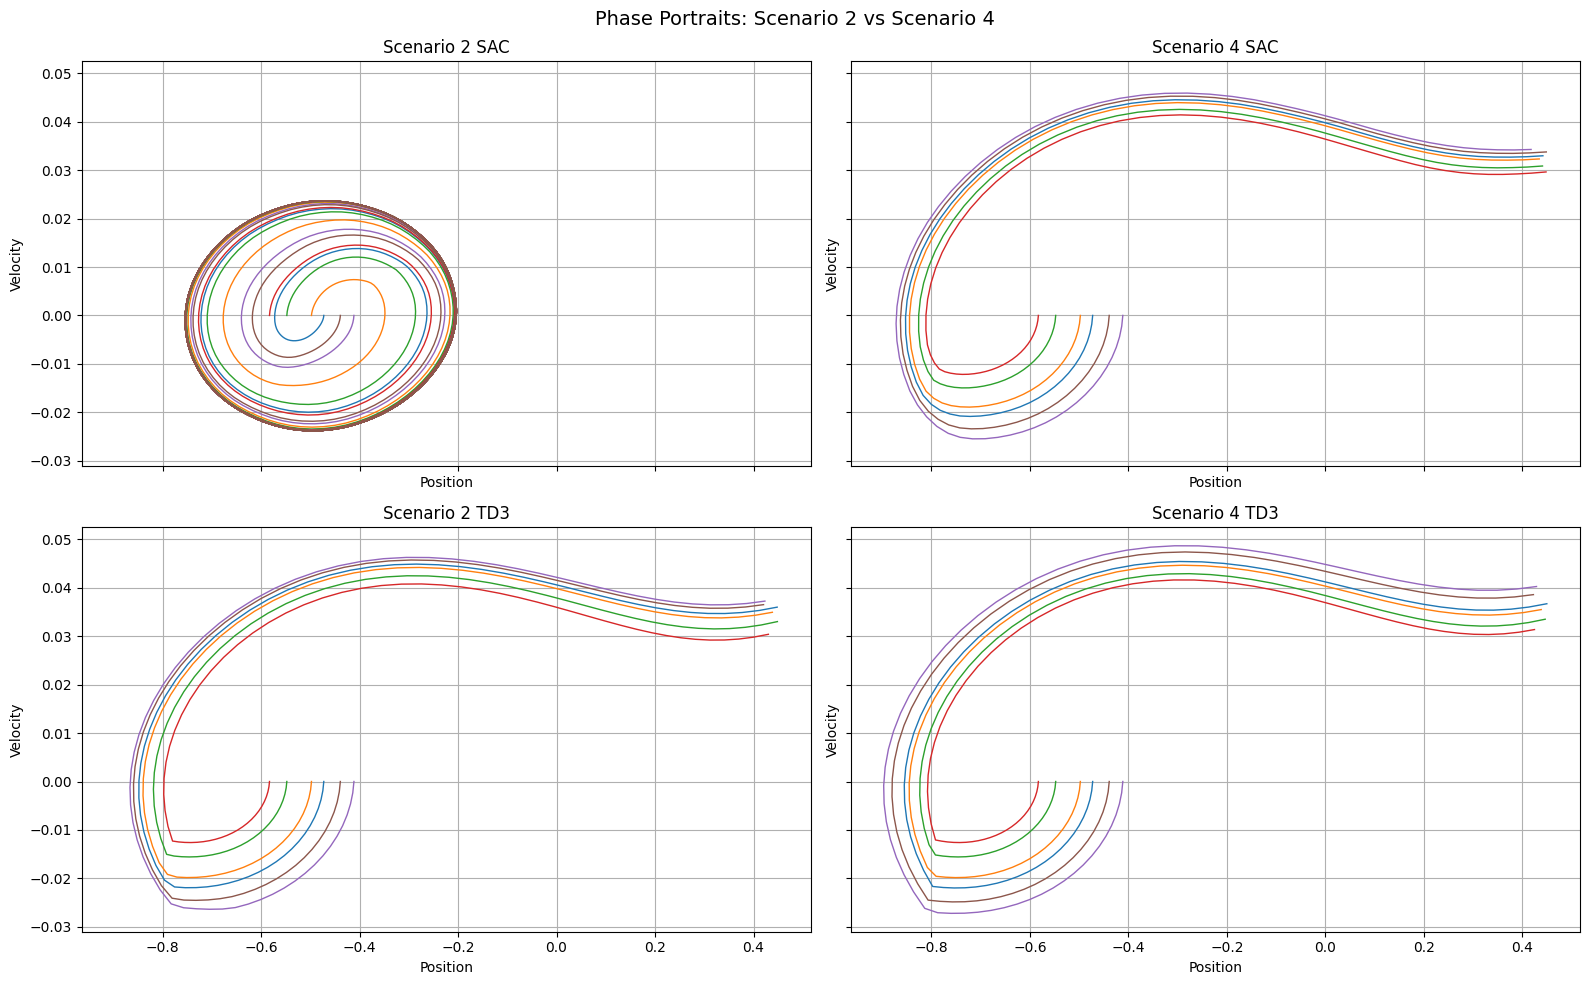

In [47]:
s2_sac_model = SAC.load(s2_root / "models/scenario2_sac")
s2_td3_model = TD3.load(s2_root / "models/scenario2_td3")

s4_sac_model = SAC.load(s4_root / "models/scenario4_sac")
s4_td3_model = TD3.load(s4_root / "models/scenario4_td3")


def run_continuous_episode(model, seed=None, max_steps=999):
    env = gym.make("MountainCarContinuous-v0")
    state, _ = env.reset(seed=seed)

    positions = []
    velocities = []

    for _ in range(max_steps):
        action, _ = model.predict(state, deterministic=True)

        positions.append(state[0])
        velocities.append(state[1])

        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

    env.close()

    return {
        "positions": positions,
        "velocities": velocities,
        "steps": len(positions)
    }


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

for seed in range(6):
    ep = run_continuous_episode(s2_sac_model, seed=seed)
    axes[0, 0].plot(ep["positions"], ep["velocities"], linewidth=1)

for seed in range(6):
    ep = run_continuous_episode(s4_sac_model, seed=seed)
    axes[0, 1].plot(ep["positions"], ep["velocities"], linewidth=1)

for seed in range(6):
    ep = run_continuous_episode(s2_td3_model, seed=seed)
    axes[1, 0].plot(ep["positions"], ep["velocities"], linewidth=1)

for seed in range(6):
    ep = run_continuous_episode(s4_td3_model, seed=seed)
    axes[1, 1].plot(ep["positions"], ep["velocities"], linewidth=1)

axes[0, 0].set_title("Scenario 2 SAC")
axes[0, 1].set_title("Scenario 4 SAC")
axes[1, 0].set_title("Scenario 2 TD3")
axes[1, 1].set_title("Scenario 4 TD3")

for ax in axes.ravel():
    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.grid(True)

plt.suptitle("Phase Portraits: Scenario 2 vs Scenario 4", fontsize=14)
plt.tight_layout()
plt.show()

**Phase portraits (Scenario 2 vs 4)**
- Scenario 2 SAC trajectories stay in the valley and fail to reach the goal.
- Scenario 4 SAC trajectories show consistent momentum-building to the right hill.
- TD3 reaches the goal in both scenarios, with slightly quicker climbs in the minimum-steps case.